## Componentes Fundamentales de un Agente - Implementación Práctica
### Módulo Educativo para Comprender la Arquitectura de Agentes

### Bibliotecas Principales Utilizadas
- dataclasses: Para crear objetos de datos estructurados que representan los componentes del agente
- typing: Para sugerencias de tipo y una mejor documentación del código
- abc: Para clases base abstractas que definen las interfaces de los componentes del agente
- logging: Para rastrear los procesos de decisión del agente y su estado interno
- datetime: Para marcar con la hora las observaciones, acciones y memorias
- enum: Para definir estados fijos del entorno y tipos de memoria

In [19]:
"""
Core Components of an Agent - Practical Implementation
Educational Module for Understanding Agent Architecture

This module demonstrates:
1. Perception: How agents sense and interpret their environment
2. Reasoning: How agents process information and make decisions
3. Action: How agents execute decisions and interact with the world
4. Memory: How agents store and retrieve information
5. Planning: How agents create and execute multi-step strategies
6. Action/Reflection Loop: The core cycle of agent behavior
"""

import json
import time
import random
from datetime import datetime, timedelta
from typing import Dict, List, Any, Optional, Tuple
from dataclasses import dataclass, field
from enum import Enum
from abc import ABC, abstractmethod
import logging

# Setup logging to see agent thoughts
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(message)s')
logger = logging.getLogger(__name__)


### Descripción Breve
Este código implementa los componentes fundamentales de un sistema de agente inteligente, demostrando cómo los agentes perciben, razonan, actúan y aprenden. Proporciona un marco práctico para comprender la arquitectura de agentes mediante interacciones simuladas con el entorno y procesos de toma de decisiones.

### Lógica del Código y Flujo: Visión General de Alto Nivel
El código establece una arquitectura de agente integral que recorre cíclicamente las fases de percepción, razonamiento y acción. El agente monitorea continuamente su entorno, procesa las observaciones a través de sus sistemas de memoria y razonamiento, planifica acciones apropiadas, las ejecuta y reflexiona sobre los resultados para mejorar decisiones futuras. Esto crea un sistema de aprendizaje de bucle cerrado donde el agente se adapta en función de la experiencia.

### Diagrama de Flujo Visual
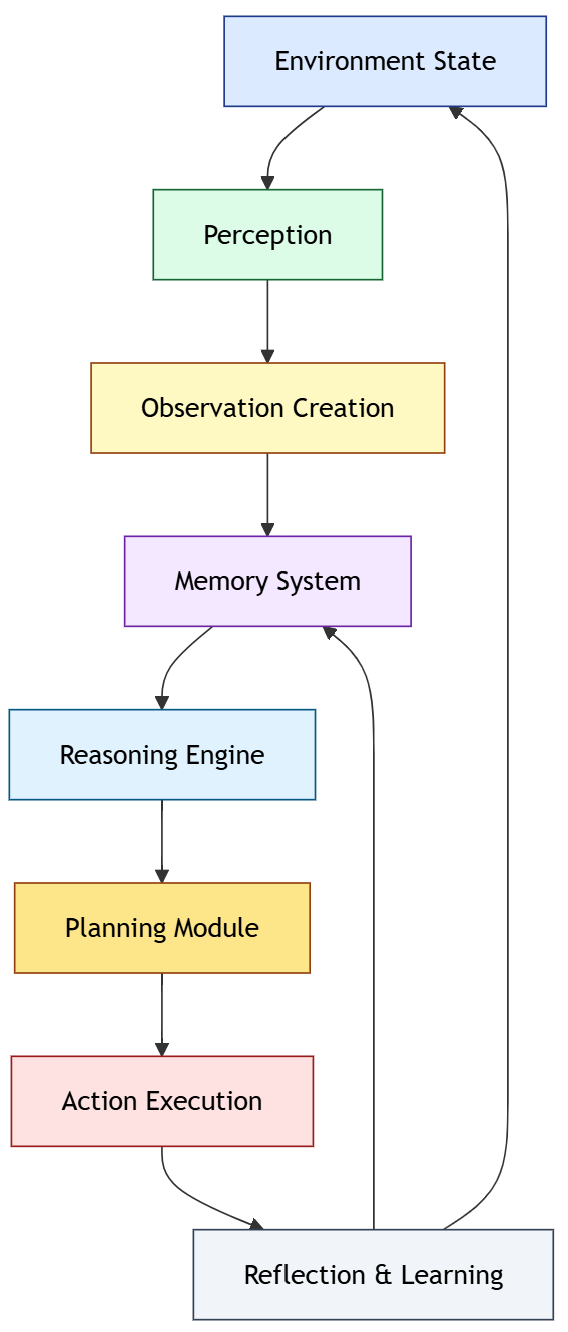

## Desglose del Código Paso a Paso

## Fundamento: Entorno y Estructuras de Datos

### Enumeración del Estado del Entorno
- Define los posibles estados del entorno (ESTABLE, CAMBIANTE, INCIERTO, CRÍTICO)
- Proporciona una representación categórica de las condiciones ambientales

### Estructura de Datos de Observación
- Representa la entrada sensorial cruda del entorno
- Incluye marca de tiempo, fuente de datos, puntuación de confianza y estado de procesamiento
- Sirve como la unidad fundamental de percepción

### Estructura de Datos de Acción
- Encapsula las acciones ejecutables con parámetros y resultados esperados
- Rastrea los costos de ejecución y las marcas de tiempo para el historial de acciones
- Define la interfaz para la interacción con el entorno

### Estructura de Datos de Memoria
- Almacena las experiencias del agente con metadatos para su recuperación
- Admite diferentes tipos de memoria (episódica, semántica, procedimental)
- Implementa la ponderación de importancia y el seguimiento de relaciones

## Implementación de los Componentes Centrales del Agente

### Sistema de Percepción

- Monitorea el estado del entorno mediante la generación de observaciones
- Filtra y procesa los datos sensoriales crudos
- Asigna puntuaciones de confianza a las observaciones

### Motor de Razonamiento
- Procesa las observaciones en relación con el conocimiento existente
- Aplica reglas lógicas y mecanismos de inferencia
- Genera posibles planes de acción según el estado actual

### Gestión de la Memoria
- Almacena y recupera experiencias y conocimientos pasados
- Implementa la priorización de la memoria mediante la puntuación de importancia
- Mantiene las relaciones entre las diferentes entradas de memoria

### Módulo de Planificación
- Desarrolla secuencias de acción de múltiples pasos
- Evalúa los costos de las acciones y los resultados esperados
- Adapta los planes según la retroalimentación del entorno

### Bucle de Acción-Reflexión
- Ejecuta las acciones planificadas en el entorno
- Observa los resultados y los compara con las expectativas
- Actualiza los modelos de memoria y razonamiento según los resultados

### Conexión con la Lección
- Arquitectura de Agentes: Demuestra el ciclo clásico de percibir-pensar-actuar discutido en la teoría de agentes
- Modularidad de Componentes: Muestra cómo los sistemas de percepción, razonamiento y acción pueden desarrollarse como módulos separados pero interconectados
- Sistemas de Memoria: Ilustra los diferentes tipos de memoria (episódica, semántica, procedimental) y sus roles en la inteligencia del agente
- Aprendizaje a través de la Experiencia: Encarna el bucle de acción/reflexión donde los agentes mejoran sus decisiones según resultados pasados
- Representación del Estado: Conecta con los conceptos de la clase sobre cómo los agentes representan internamente los estados del entorno
- Toma de Decisiones bajo Incertidumbre: Muestra la puntuación de confianza y cómo los agentes manejan información imperfecta
- Comportamiento Adaptativo: Demuestra cómo los agentes pueden modificar su comportamiento según la retroalimentación del entorno y la experiencia acumulada

In [20]:
# FOUNDATION: ENVIRONMENT AND BASIC DATA STRUCTURES

class EnvironmentState(Enum):
    STABLE = "stable"
    CHANGING = "changing"
    UNCERTAIN = "uncertain"
    CRITICAL = "critical"

@dataclass
class Observation:
    """Raw sensory data from the environment"""
    timestamp: datetime
    source: str
    data: Dict[str, Any]
    confidence: float = 1.0
    processed: bool = False

@dataclass
class Action:
    """Represents an action the agent can take"""
    action_type: str
    parameters: Dict[str, Any]
    expected_outcome: str
    cost: float = 0.0
    timestamp: datetime = field(default_factory=datetime.now)

@dataclass
class Memory:
    """Memory entry with metadata"""
    content: Any
    memory_type: str  # episodic, semantic, procedural
    importance: float
    timestamp: datetime
    access_count: int = 0
    related_memories: List[str] = field(default_factory=list)
    memory_id: str = ""  # Added to track memory ID

### Descripción Breve
Este código implementa un sofisticado sistema de percepción que procesa múltiples entradas sensoriales (visual, auditiva, textual, temporal, social) y aplica un filtrado por atención para priorizar las observaciones importantes. Demuestra cómo los agentes pueden enfocarse selectivamente en la información ambiental relevante mientras ignoran el ruido.

### Lógica del Código y Flujo: Visión General de Alto Nivel
El sistema de percepción opera como un pipeline de múltiples etapas que comienza con la recopilación de datos ambientales crudos a través de sensores especializados, procesa cada modalidad sensorial de forma independiente, aplica la puntuación de confianza y luego usa un mecanismo de atención para filtrar y priorizar las observaciones según umbrales de importancia y relevancia, antes de almacenarlas en el historial de percepción.

### Diagrama de Flujo Visual
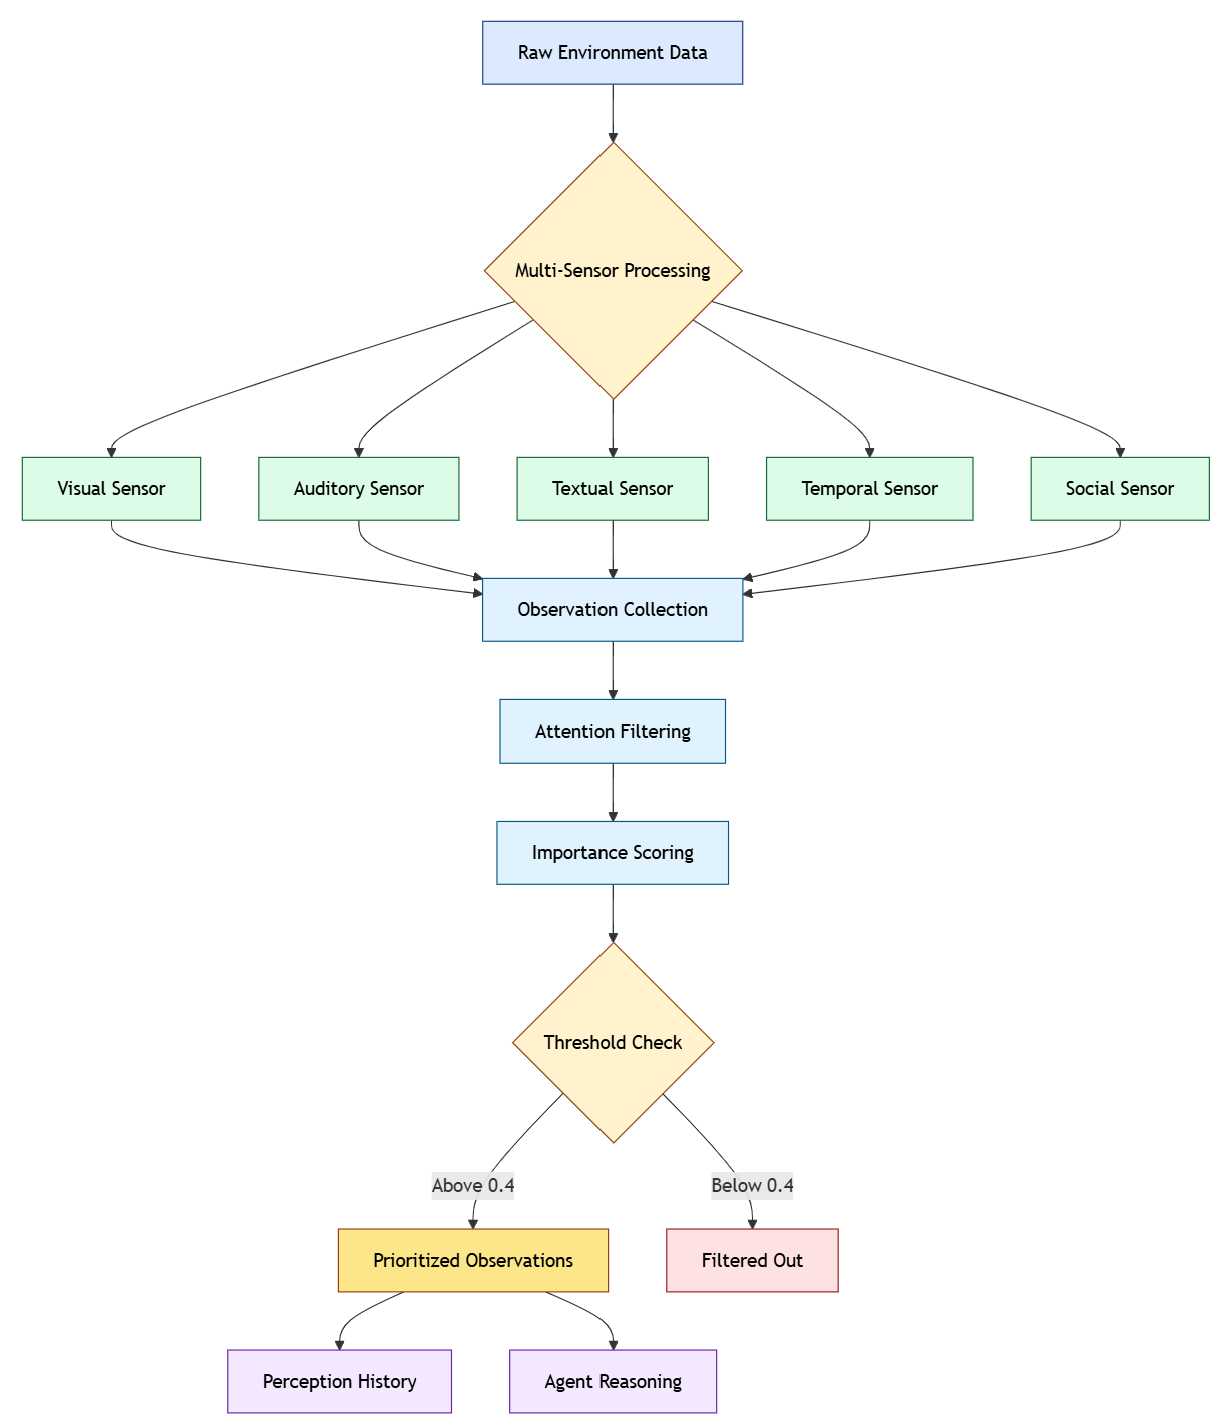

## Desglose del Código Paso a Paso

## Inicialización y Configuración de Sensores

### Configuración de Sensores Multimodales
- Define cinco sensores especializados que cubren diferentes dominios de percepción
- Asigna pesos de atención para priorizar las entradas sensoriales (visual y textual con la mayor prioridad)
- Inicializa el historial de percepción para rastrear los patrones observacionales a lo largo del tiempo

### Interfaz Principal de Percepción
- Coordina el procesamiento en paralelo de todos los datos ambientales disponibles
- Enruta los datos a los procesadores de sensores especializados apropiados
- Gestiona el ciclo de vida completo de la observación, desde los datos crudos hasta las salidas filtradas

## Procesamiento de Sensores Especializados

### Procesamiento del Sensor Visual
- Detecta y procesa objetos con información de posición y atributos
- Analiza el contexto de la escena, incluyendo las condiciones de iluminación
- Aplica la puntuación de confianza según la claridad visual

### Procesamiento del Sensor Auditivo
- Procesa la información sonora, incluyendo tipo, volumen y dirección
- Usa niveles de confianza moderados para la percepción auditiva
- Captura patrones y secuencias sonoras temporales

### Procesamiento del Sensor Textual
- Analiza el contenido del mensaje en busca de urgencia y sentimiento
- Implementa la detección de urgencia basada en palabras clave
- Aplica el análisis de sentimiento mediante la coincidencia de palabras positivas
- Usa una puntuación de alta confianza para los datos textuales

### Procesamiento del Sensor Temporal
- Rastrea la información de hora actual, día de la semana y hora
- Categoriza el tiempo en períodos (mañana, tarde, noche, madrugada)
- Mantiene una confianza perfecta para los datos temporales

### Procesamiento del Sensor Social
- Monitorea la presencia de personas y el contexto social
- Rastrea los estados de ánimo y actividades individuales
- Aplica el análisis de relaciones e interacciones sociales

## Sistema de Atención y Filtrado

### Aplicación del Mecanismo de Atención
- Combina pesos de atención fijos con la puntuación de importancia dinámica
- Calcula las puntuaciones de atención finales para cada observación
- Aplica un filtrado basado en umbrales para eliminar los datos de baja prioridad

### Lógica de Cálculo de la Importancia
- Usa las puntuaciones de confianza base como fundamento de la importancia
- Aplica un aumento de importancia basado en el contenido para los mensajes urgentes
- Incrementa la importancia para las señales sociales, como la detección de personas
- Realza la importancia para los eventos auditivos fuertes

### Conexión con la Lección
- Atención Selectiva: Demuestra cómo los agentes se enfocan en la información relevante mientras filtran el ruido, conectando con las teorías de arquitectura cognitiva
- Percepción Multimodal: Muestra la integración de diferentes entradas sensoriales, relacionándose con los principios de la cognición corporizada
- Confianza e Incertidumbre: Implementa la puntuación de confianza para las observaciones, vinculándose con los conceptos de razonamiento probabilístico
- Pesos de Atención: Ilustra cómo se pueden priorizar las diferentes modalidades sensoriales, conectando con la asignación de recursos en la racionalidad limitada
- Historial de Percepción: Encarna el concepto de memoria perceptiva y contexto temporal en la toma de decisiones
- Mecanismos de Umbral: Muestra cómo los agentes toman decisiones binarias sobre qué procesar, relacionándose con las teorías del umbral de activación
- Procesamiento en Tiempo Real: Demuestra el monitoreo ambiental continuo, conectando con la acción situada y los requisitos de los agentes en tiempo real

In [21]:
# COMPONENT 1: PERCEPTION SYSTEM

class PerceptionSystem:
    """
    Handles sensing and interpreting environmental information
    Demonstrates filtering, pattern recognition, and attention mechanisms
    """
    
    def __init__(self):
        self.sensors = {
            "visual": self._visual_sensor,
            "auditory": self._auditory_sensor,
            "textual": self._textual_sensor,
            "temporal": self._temporal_sensor,
            "social": self._social_sensor
        }
        self.attention_weights = {
            "visual": 0.3,
            "auditory": 0.2,
            "textual": 0.3,
            "temporal": 0.1,
            "social": 0.1
        }
        self.perception_history = []
    
    def perceive(self, environment_data: Dict[str, Any]) -> List[Observation]:
        """
        Main perception function - converts raw environment data to observations
        """
        observations = []
        
        for sensor_name, sensor_func in self.sensors.items():
            if sensor_name in environment_data:
                raw_data = environment_data[sensor_name]
                processed_obs = sensor_func(raw_data)
                observations.extend(processed_obs)
        
        # Apply attention mechanism
        filtered_observations = self._apply_attention_filter(observations)
        
        # Store perception history
        self.perception_history.extend(filtered_observations)
        
        logger.info(f"🔍 Perceived {len(filtered_observations)} significant observations")
        return filtered_observations
    
    def _visual_sensor(self, data: Dict) -> List[Observation]:
        """Process visual information"""
        observations = []
        
        if "objects" in data:
            for obj in data["objects"]:
                confidence = 0.9 if obj.get("clear", True) else 0.6
                obs = Observation(
                    timestamp=datetime.now(),
                    source="visual",
                    data={"object": obj["name"], "position": obj.get("position"), "attributes": obj.get("attributes", {})},
                    confidence=confidence
                )
                observations.append(obs)
        
        if "scene" in data:
            scene_obs = Observation(
                timestamp=datetime.now(),
                source="visual",
                data={"scene_type": data["scene"], "lighting": data.get("lighting", "normal")},
                confidence=0.8
            )
            observations.append(scene_obs)
        
        return observations
    
    def _auditory_sensor(self, data: Dict) -> List[Observation]:
        """Process auditory information"""
        observations = []
        
        if "sounds" in data:
            for sound in data["sounds"]:
                obs = Observation(
                    timestamp=datetime.now(),
                    source="auditory",
                    data={"sound_type": sound["type"], "volume": sound.get("volume", 50), "source_direction": sound.get("direction")},
                    confidence=0.7
                )
                observations.append(obs)
        
        return observations
    
    def _textual_sensor(self, data: Dict) -> List[Observation]:
        """Process textual information"""
        observations = []
        
        if "messages" in data:
            for message in data["messages"]:
                # Simple sentiment and urgency detection
                urgency = 0.8 if any(word in message.lower() for word in ["urgent", "asap", "emergency"]) else 0.3
                sentiment = "positive" if any(word in message.lower() for word in ["good", "great", "excellent"]) else "neutral"
                
                obs = Observation(
                    timestamp=datetime.now(),
                    source="textual",
                    data={"content": message, "urgency": urgency, "sentiment": sentiment},
                    confidence=0.9
                )
                observations.append(obs)
        
        return observations
    
    def _temporal_sensor(self, data: Dict) -> List[Observation]:
        """Process temporal information"""
        current_time = datetime.now()
        
        obs = Observation(
            timestamp=current_time,
            source="temporal",
            data={
                "current_time": current_time,
                "day_of_week": current_time.weekday(),
                "hour": current_time.hour,
                "time_period": self._get_time_period(current_time.hour)
            },
            confidence=1.0
        )
        
        return [obs]
    
    def _social_sensor(self, data: Dict) -> List[Observation]:
        """Process social context information"""
        observations = []
        
        if "people_present" in data:
            for person in data["people_present"]:
                obs = Observation(
                    timestamp=datetime.now(),
                    source="social",
                    data={"person": person["name"], "mood": person.get("mood", "neutral"), "activity": person.get("activity")},
                    confidence=0.7
                )
                observations.append(obs)
        
        return observations
    
    def _apply_attention_filter(self, observations: List[Observation]) -> List[Observation]:
        """Filter observations based on attention weights and importance"""
        filtered = []
        
        for obs in observations:
            attention_score = self.attention_weights.get(obs.source, 0.1)
            importance_score = self._calculate_importance(obs)
            
            final_score = (attention_score + importance_score) / 2
            
            if final_score > 0.4:  # Attention threshold
                filtered.append(obs)
        
        return sorted(filtered, key=lambda x: self._calculate_importance(x), reverse=True)
    
    def _calculate_importance(self, obs: Observation) -> float:
        """Calculate importance of an observation"""
        base_importance = obs.confidence
        
        # Boost importance based on content
        if obs.source == "textual" and obs.data.get("urgency", 0) > 0.5:
            base_importance += 0.3
        
        if obs.source == "visual" and "person" in str(obs.data).lower():
            base_importance += 0.2
        
        if obs.source == "auditory" and obs.data.get("volume", 0) > 80:
            base_importance += 0.2
        
        return min(base_importance, 1.0)
    
    def _get_time_period(self, hour: int) -> str:
        """Convert hour to time period"""
        if 5 <= hour < 12:
            return "morning"
        elif 12 <= hour < 17:
            return "afternoon"
        elif 17 <= hour < 21:
            return "evening"
        else:
            return "night"

### Descripción Breve
Este código implementa un sofisticado sistema de razonamiento que emplea cuatro estrategias de razonamiento distintas (causal, probabilística, deductiva, analógica) para procesar observaciones y tomar decisiones. Demuestra cómo los agentes pueden analizar patrones, extraer inferencias y sintetizar conclusiones a partir de datos ambientales usando múltiples enfoques cognitivos.

### Lógica del Código y Flujo: Visión General de Alto Nivel
El sistema de razonamiento opera como un pipeline analítico de múltiples etapas que comienza con el análisis de observaciones, avanza a través de la identificación de patrones, aplica estrategias de razonamiento apropiadas al contexto y culmina en conclusiones sintetizadas. El sistema mantiene un historial de sesiones de razonamiento para apoyar el razonamiento analógico y el aprendizaje continuo a partir de experiencias pasadas.

### Diagrama de Flujo Visual
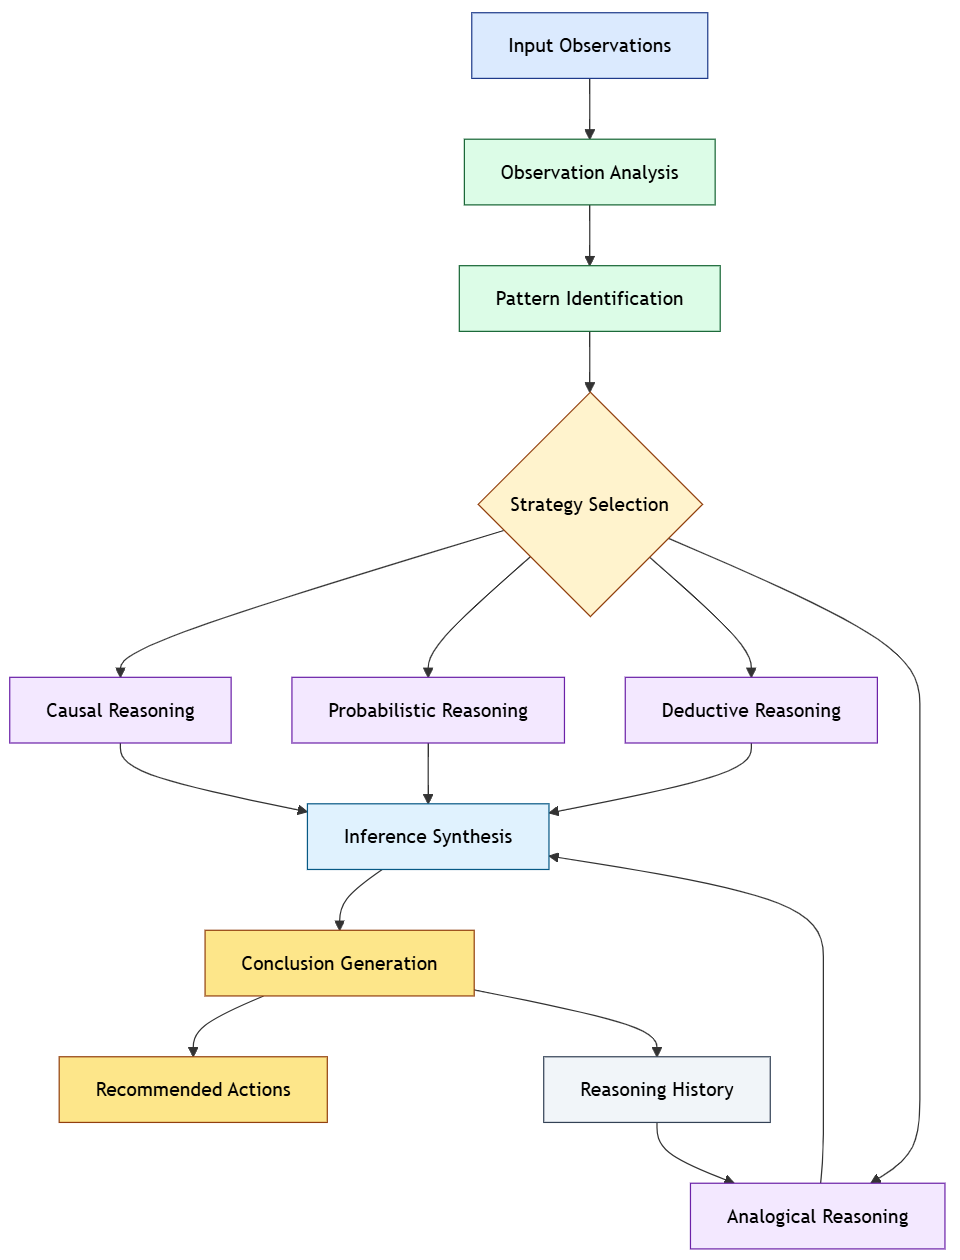

## Desglose del Código Paso a Paso
## Gestión de la Sesión de Razonamiento

### Inicialización y Seguimiento de la Sesión
- Crea sesiones de razonamiento estructuradas con marcas de tiempo y contexto
- Rastrea todos los pasos de razonamiento para la transparencia y el análisis histórico
- Mantiene un historial de razonamiento completo para referencia analógica futura

### Pipeline de Razonamiento de Múltiples Etapas
- Implementa el procesamiento secuencial desde las observaciones crudas hasta las conclusiones finales
- Documenta cada paso de razonamiento para la IA explicable y la depuración
- Garantiza un análisis integral mediante un enfoque sistemático

## Fase de Análisis de Observaciones

### Categorización Integral de Datos
- Analiza las observaciones por fuente sensorial (visual, auditiva, textual, etc.)
- Calcula los niveles de confianza promedio entre todas las observaciones
- Identifica los indicadores de urgencia y las entidades clave en el entorno
- Proporciona una visión estadística de la calidad y distribución de las observaciones

### Evaluación de la Confianza y la Urgencia
- Agrega las puntuaciones de confianza para evaluar la fiabilidad general de los datos
- Marca las observaciones de alta urgencia para su procesamiento prioritario
- Extrae las entidades clave (personas, objetos) para un razonamiento enfocado

## Sistema de Identificación de Patrones

### Reconocimiento de Patrones Temporales
- Analiza las secuencias de tiempo entre observaciones
- Detecta patrones temporales regulares frente a irregulares
- Identifica posibles secuencias causales según la proximidad temporal

### Detección de Relaciones y Anomalías
- Identifica posibles relaciones causales entre diferentes tipos de observación
- Detecta correlaciones entre modalidades sensoriales
- Marca anomalías como observaciones de baja confianza o datos inconsistentes

## Motor de Razonamiento de Múltiples Estrategias

### Selección de Estrategia Consciente del Contexto
- Selecciona dinámicamente las estrategias de razonamiento según las características de las observaciones
- Usa el razonamiento causal para datos secuenciales con múltiples observaciones
- Aplica el razonamiento probabilístico cuando se detecta incertidumbre
- Activa el razonamiento deductivo para contextos específicos orientados a objetivos
- Utiliza el razonamiento analógico cuando hay datos históricos disponibles

### Implementación del Razonamiento Causal
- Construye cadenas causales según la proximidad temporal
- Calcula la fuerza causal entre eventos secuenciales
- Identifica posibles relaciones de causa-efecto en las secuencias de observación

### Sistema de Razonamiento Probabilístico
- Cuantifica las incertidumbres en los datos observacionales
- Calcula las probabilidades de resultado según la evidencia de apoyo
- Ajusta la confianza del razonamiento según los niveles de incertidumbre

### Aplicación de la Lógica Deductiva
- Extrae premisas de alta confianza de las observaciones
- Aplica reglas lógicas para derivar conclusiones
- Valida la consistencia lógica de las conclusiones derivadas

### Mecanismo de Razonamiento Analógico
- Compara la situación actual con sesiones de razonamiento pasadas
- Calcula la similitud situacional usando métricas basadas en texto
- Aprovecha las conclusiones históricas para la toma de decisiones actual

## Síntesis de Conclusiones y Planificación de Acciones

### Integración de Conclusiones de Múltiples Estrategias
- Combina las inferencias de todas las estrategias de razonamiento aplicadas
- Identifica el método de razonamiento principal con la mayor confianza
- Calcula la confianza general de la decisión según las fortalezas de las estrategias

### Generación de Recomendaciones de Acción
- Genera acciones específicas al contexto según el tipo de razonamiento principal
- Proporciona acciones de razonamiento causal: abordar las causas raíz y monitorear los efectos
- Sugiere acciones de razonamiento probabilístico: recopilar información y preparar contingencias
- Recomienda acciones de razonamiento deductivo: ejecutar conclusiones y verificar premisas
- Propone acciones de razonamiento analógico: aplicar soluciones pasadas y adaptarse al contexto

### Conexión con la Lección
- Múltiples Estrategias de Razonamiento: Demuestra cómo los agentes pueden emplear diferentes enfoques cognitivos, conectando con la teoría del proceso dual y el razonamiento de múltiples estrategias
- Confianza e Incertidumbre: Implementa el razonamiento probabilístico bajo incertidumbre, relacionándose con los conceptos del razonamiento bayesiano
- Reconocimiento de Patrones: Muestra cómo los agentes identifican patrones temporales y causales, vinculándose con las teorías cognitivas del reconocimiento de patrones
- Aprendizaje Analógico: Encarna el razonamiento basado en casos y el aprendizaje a partir de la experiencia, conectando con el razonamiento analógico en las ciencias cognitivas
- IA Explicable: Mantiene el historial y los pasos de razonamiento para la transparencia, relacionándose con la IA interpretable y la toma de decisiones explicable
- Procesamiento Consciente del Contexto: Demuestra la selección adaptativa de estrategias según el contexto situacional, conectando con la cognición situada
- Síntesis de Decisiones: Muestra cómo se pueden integrar múltiples enfoques de razonamiento, relacionándose con la integración cognitiva y la formación de consensos
- Generación de Acciones: Vincula los resultados del razonamiento con acciones específicas, demostrando el bucle cognición-acción en los sistemas inteligentes

In [22]:
# COMPONENT 2: REASONING SYSTEM

class ReasoningSystem:
    """
    Handles decision-making, inference, and logical reasoning
    Demonstrates different reasoning patterns and strategies
    """
    
    def __init__(self):
        self.knowledge_base = {}
        self.reasoning_strategies = {
            "causal": self._causal_reasoning,
            "analogical": self._analogical_reasoning,
            "deductive": self._deductive_reasoning,
            "probabilistic": self._probabilistic_reasoning
        }
        self.reasoning_history = []
    
    def reason(self, observations: List[Observation], context: Dict[str, Any], goal: str = None) -> Dict[str, Any]:
        """
        Main reasoning function - processes observations and produces decisions
        """
        reasoning_session = {
            "timestamp": datetime.now(),
            "observations_count": len(observations),
            "context": context,
            "goal": goal,
            "reasoning_steps": [],
            "conclusion": None
        }
        
        # Step 1: Analyze observations
        analysis = self._analyze_observations(observations)
        reasoning_session["reasoning_steps"].append(("analyze_observations", analysis))
        
        # Step 2: Identify patterns and relationships
        patterns = self._identify_patterns(observations, context)
        reasoning_session["reasoning_steps"].append(("identify_patterns", patterns))
        
        # Step 3: Apply reasoning strategies
        inferences = []
        for strategy_name, strategy_func in self.reasoning_strategies.items():
            if self._should_use_strategy(strategy_name, observations, context):
                inference = strategy_func(observations, patterns, context)
                inferences.append((strategy_name, inference))
                reasoning_session["reasoning_steps"].append((f"reasoning_{strategy_name}", inference))
        
        # Step 4: Synthesize conclusion
        conclusion = self._synthesize_conclusions(inferences, goal)
        reasoning_session["conclusion"] = conclusion
        
        self.reasoning_history.append(reasoning_session)
        
        logger.info(f"🧠 Reasoning complete: {conclusion['decision_type']} with {conclusion['confidence']:.2f} confidence")
        
        return conclusion
    
    def _analyze_observations(self, observations: List[Observation]) -> Dict[str, Any]:
        """Analyze and categorize observations"""
        analysis = {
            "total_observations": len(observations),
            "by_source": {},
            "confidence_levels": [],
            "urgency_indicators": [],
            "key_entities": []
        }
        
        for obs in observations:
            # Categorize by source
            source = obs.source
            if source not in analysis["by_source"]:
                analysis["by_source"][source] = []
            analysis["by_source"][source].append(obs.data)
            
            # Collect confidence levels
            analysis["confidence_levels"].append(obs.confidence)
            
            # Detect urgency
            if obs.data.get("urgency", 0) > 0.5:
                analysis["urgency_indicators"].append(obs.data)
            
            # Extract key entities
            if "person" in str(obs.data).lower():
                analysis["key_entities"].append("person")
            if "object" in str(obs.data).lower():
                analysis["key_entities"].append("object")
        
        analysis["average_confidence"] = sum(analysis["confidence_levels"]) / len(analysis["confidence_levels"]) if analysis["confidence_levels"] else 0
        
        return analysis
    
    def _identify_patterns(self, observations: List[Observation], context: Dict[str, Any]) -> Dict[str, Any]:
        """Identify patterns and relationships in observations"""
        patterns = {
            "temporal_patterns": [],
            "causal_relationships": [],
            "correlations": [],
            "anomalies": []
        }
        
        # Temporal patterns
        time_sorted_obs = sorted(observations, key=lambda x: x.timestamp)
        if len(time_sorted_obs) > 1:
            time_gaps = [(time_sorted_obs[i+1].timestamp - time_sorted_obs[i].timestamp).total_seconds() 
                        for i in range(len(time_sorted_obs)-1)]
            if max(time_gaps) > 300:  # 5 minutes
                patterns["temporal_patterns"].append("irregular_timing")
            else:
                patterns["temporal_patterns"].append("regular_sequence")
        
        # Simple causal relationship detection
        textual_obs = [obs for obs in observations if obs.source == "textual"]
        auditory_obs = [obs for obs in observations if obs.source == "auditory"]
        
        if textual_obs and auditory_obs:
            patterns["causal_relationships"].append("communication_activity")
        
        # Anomaly detection (simplified)
        confidence_scores = [obs.confidence for obs in observations]
        avg_confidence = sum(confidence_scores) / len(confidence_scores) if confidence_scores else 0
        low_confidence_obs = [obs for obs in observations if obs.confidence < avg_confidence - 0.2]
        
        if low_confidence_obs:
            patterns["anomalies"].append("low_confidence_observations")
        
        return patterns
    
    def _should_use_strategy(self, strategy: str, observations: List[Observation], context: Dict[str, Any]) -> bool:
        """Determine which reasoning strategies to apply"""
        if strategy == "causal" and len(observations) > 2:
            return True
        elif strategy == "probabilistic" and any("uncertain" in str(obs.data).lower() for obs in observations):
            return True
        elif strategy == "deductive" and context.get("goal_type") == "specific":
            return True
        elif strategy == "analogical" and len(self.reasoning_history) > 0:
            return True
        return False
    
    def _causal_reasoning(self, observations: List[Observation], patterns: Dict, context: Dict) -> Dict[str, Any]:
        """Apply causal reasoning"""
        causal_chains = []
        
        # Simple causal chain detection
        time_sorted = sorted(observations, key=lambda x: x.timestamp)
        for i in range(len(time_sorted) - 1):
            current = time_sorted[i]
            next_obs = time_sorted[i + 1]
            
            # If observations are close in time, assume potential causality
            time_diff = (next_obs.timestamp - current.timestamp).total_seconds()
            if time_diff < 60:  # Within 1 minute
                causal_chains.append({
                    "cause": current.data,
                    "effect": next_obs.data,
                    "confidence": min(current.confidence, next_obs.confidence)
                })
        
        return {
            "causal_chains": causal_chains,
            "reasoning_type": "causal",
            "strength": len(causal_chains) / max(len(observations) - 1, 1)
        }
    
    def _probabilistic_reasoning(self, observations: List[Observation], patterns: Dict, context: Dict) -> Dict[str, Any]:
        """Apply probabilistic reasoning"""
        uncertainties = []
        probabilities = {}
        
        for obs in observations:
            if obs.confidence < 0.8:
                uncertainties.append(obs)
        
        # Calculate outcome probabilities (simplified)
        if context.get("possible_outcomes"):
            for outcome in context["possible_outcomes"]:
                supporting_evidence = sum(1 for obs in observations 
                                        if outcome.lower() in str(obs.data).lower())
                total_evidence = len(observations)
                probabilities[outcome] = supporting_evidence / total_evidence if total_evidence > 0 else 0
        
        return {
            "uncertainties": len(uncertainties),
            "outcome_probabilities": probabilities,
            "reasoning_type": "probabilistic",
            "confidence_in_reasoning": 1 - (len(uncertainties) / len(observations)) if observations else 0
        }
    
    def _deductive_reasoning(self, observations: List[Observation], patterns: Dict, context: Dict) -> Dict[str, Any]:
        """Apply deductive reasoning"""
        premises = []
        conclusions = []
        
        # Extract premises from high-confidence observations
        high_confidence_obs = [obs for obs in observations if obs.confidence > 0.8]
        premises = [obs.data for obs in high_confidence_obs]
        
        # Apply logical rules (simplified)
        if len(premises) >= 2:
            # Example: If urgent message + person present = immediate action needed
            has_urgency = any("urgency" in str(p) for p in premises)
            has_person = any("person" in str(p) for p in premises)
            
            if has_urgency and has_person:
                conclusions.append("immediate_attention_required")
            elif has_urgency:
                conclusions.append("priority_action_needed")
            elif has_person:
                conclusions.append("social_interaction_opportunity")
        
        return {
            "premises": premises,
            "conclusions": conclusions,
            "reasoning_type": "deductive",
            "logical_validity": len(conclusions) > 0
        }
    
    def _analogical_reasoning(self, observations: List[Observation], patterns: Dict, context: Dict) -> Dict[str, Any]:
        """Apply analogical reasoning using past experiences"""
        analogies = []
        
        if self.reasoning_history:
            current_situation = {
                "observation_types": [obs.source for obs in observations],
                "patterns": list(patterns.keys()),
                "context_keys": list(context.keys())
            }
            
            for past_session in self.reasoning_history[-5:]:  # Check last 5 sessions
                past_situation = {
                    "observation_types": [step[1].get("by_source", {}).keys() if isinstance(step[1], dict) else [] 
                                        for step in past_session["reasoning_steps"] if step[0] == "analyze_observations"],
                    "context_keys": list(past_session["context"].keys())
                }
                
                # Calculate similarity (simplified)
                similarity = self._calculate_similarity(current_situation, past_situation)
                if similarity > 0.5:
                    analogies.append({
                        "past_situation": past_session["context"],
                        "past_conclusion": past_session["conclusion"],
                        "similarity": similarity
                    })
        
        return {
            "analogies": analogies,
            "reasoning_type": "analogical",
            "analogy_strength": max([a["similarity"] for a in analogies]) if analogies else 0
        }
    
    def _calculate_similarity(self, situation1: Dict, situation2: Dict) -> float:
        """Calculate similarity between two situations"""
        # Simple Jaccard similarity
        set1 = set(str(situation1).lower().split())
        set2 = set(str(situation2).lower().split())
        
        intersection = len(set1 & set2)
        union = len(set1 | set2)
        
        return intersection / union if union > 0 else 0
    
    def _synthesize_conclusions(self, inferences: List[Tuple[str, Dict]], goal: str = None) -> Dict[str, Any]:
        """Synthesize final conclusions from all reasoning strategies"""
        synthesis = {
            "decision_type": "composite",
            "confidence": 0.0,
            "primary_reasoning": None,
            "supporting_evidence": [],
            "recommended_actions": [],
            "reasoning_strategies_used": [inf[0] for inf in inferences]
        }
        
        # Identify primary reasoning method
        strategy_strengths = {}
        for strategy_name, inference in inferences:
            strength = 0
            if inference.get("strength"): 
                strength = inference["strength"]
            elif inference.get("confidence_in_reasoning"): 
                strength = inference["confidence_in_reasoning"]
            elif inference.get("logical_validity"): 
                strength = 0.8 if inference["logical_validity"] else 0.2
            elif inference.get("analogy_strength"): 
                strength = inference["analogy_strength"]
            
            strategy_strengths[strategy_name] = strength
        
        if strategy_strengths:
            synthesis["primary_reasoning"] = max(strategy_strengths.items(), key=lambda x: x[1])[0]
            synthesis["confidence"] = max(strategy_strengths.values())
        
        # Generate recommendations based on strongest reasoning
        if synthesis["primary_reasoning"] == "causal":
            synthesis["recommended_actions"] = ["address_root_cause", "monitor_effects"]
        elif synthesis["primary_reasoning"] == "probabilistic":
            synthesis["recommended_actions"] = ["gather_more_information", "prepare_contingencies"]
        elif synthesis["primary_reasoning"] == "deductive":
            synthesis["recommended_actions"] = ["execute_logical_conclusion", "verify_premises"]
        elif synthesis["primary_reasoning"] == "analogical":
            synthesis["recommended_actions"] = ["apply_past_solution", "adapt_to_current_context"]
        
        return synthesis

### Descripción Breve
Este código implementa un sistema de acción integral que traduce las conclusiones del razonamiento en acciones concretas ejecutables, gestiona la ejecución de acciones con monitoreo del éxito y mantiene un historial de acciones para el aprendizaje. Demuestra cómo los agentes cierran la brecha entre el razonamiento cognitivo y las capacidades de interacción física en su entorno.

### Lógica del Código y Flujo: Visión General de Alto Nivel
El sistema de acción opera como un motor de traducción y ejecución que convierte las recomendaciones abstractas del razonamiento en acciones específicas y ejecutables. Gestiona el ciclo de vida completo de la acción, desde la selección basada en las conclusiones del razonamiento, pasando por la ejecución con monitoreo del éxito, hasta el seguimiento de resultados y el registro histórico para el aprendizaje y la adaptación futuros.

### Diagrama de Flujo Visual
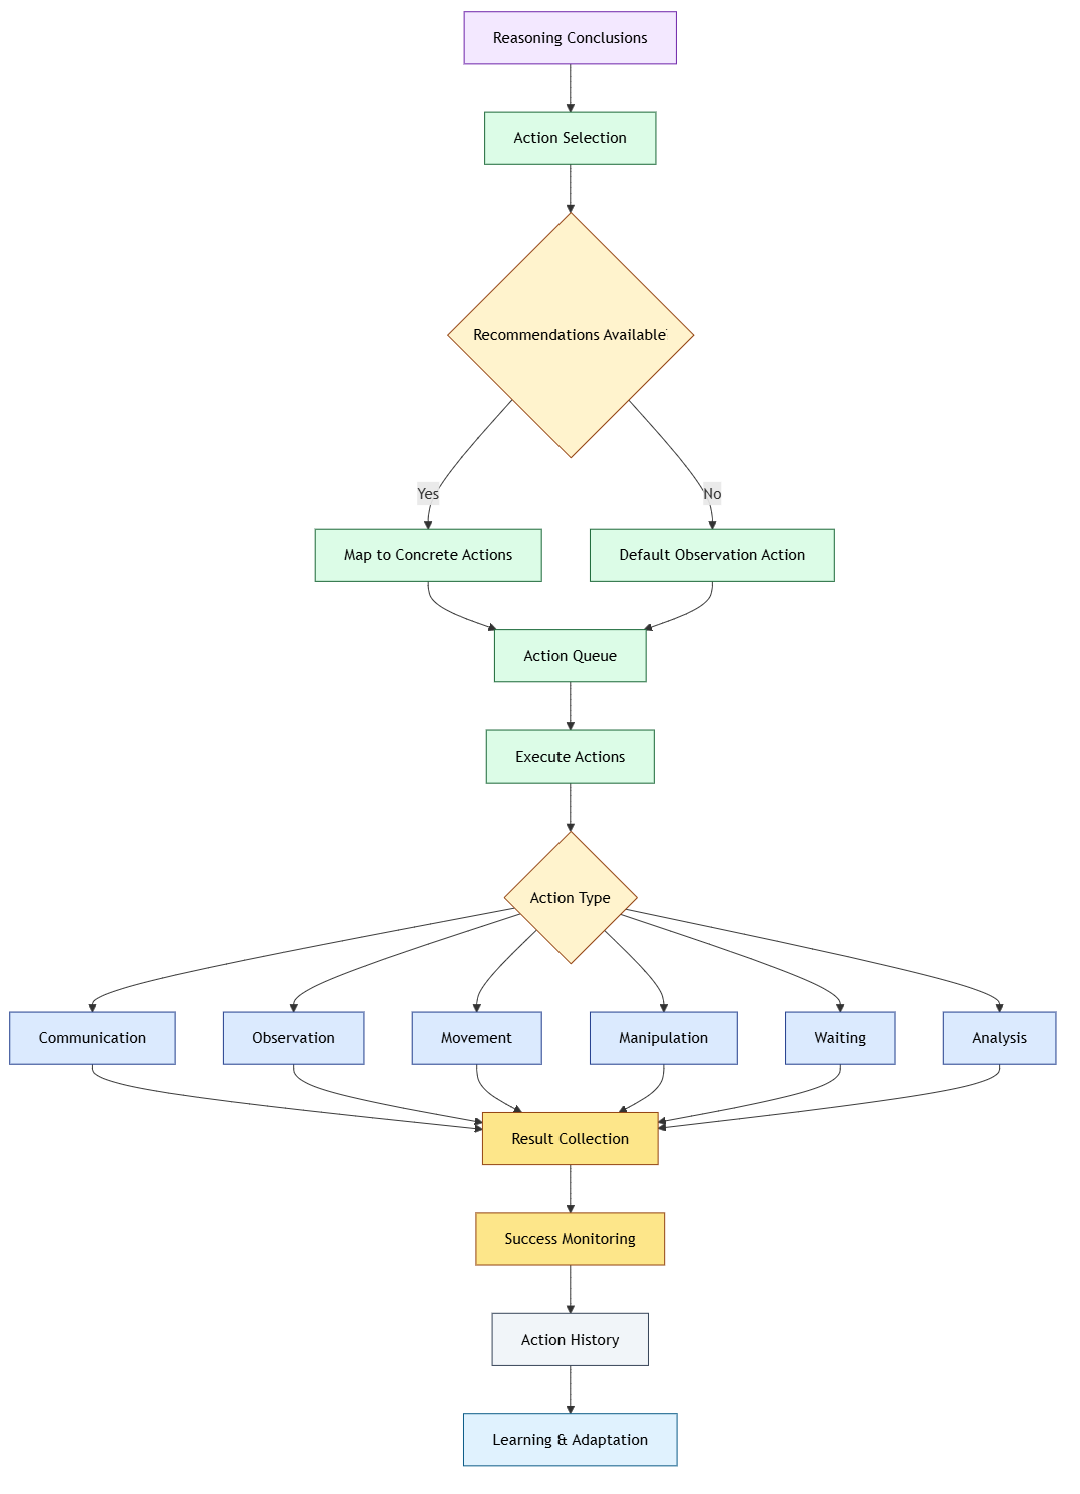

## Desglose del Código Paso a Paso
## Selección y Mapeo de Acciones
### Traducción de Recomendación a Acción
- Mapea las recomendaciones abstractas del razonamiento a acciones específicas ejecutables
- Proporciona implementaciones concretas para cada tipo de resultado de razonamiento
- Incluye una reserva a la observación exploratoria cuando no se recomiendan acciones específicas

### Registro de Tipos de Acción
- Mantiene un catálogo de los tipos de acción disponibles con sus implementaciones
- Admite seis categorías de acción centrales que cubren la mayoría de las necesidades de interacción del agente
- Permite un sistema de acción extensible mediante una interfaz estandarizada

## Marco de Ejecución de Acciones
### Gestión y Monitoreo de la Ejecución
- Rastrea el tiempo de inicio y la duración de la ejecución para el monitoreo del rendimiento
- Maneja tanto los tipos de acción conocidos como los desconocidos con un manejo de errores apropiado
- Añade metadatos completos a los resultados de la ejecución para su análisis

### Seguimiento del Éxito y Mantenimiento del Historial
- Registra todas las ejecuciones de acciones con sus parámetros y resultados
- Mantiene un historial de acciones completo para el análisis de patrones y el aprendizaje
- Proporciona contexto de ejecución para futuras decisiones de selección de acciones

## Implementaciones de las Acciones Centrales
### Sistema de Acción de Comunicación
- Maneja la comunicación del agente con diferentes niveles de urgencia y destinatarios
- Simula las probabilidades de éxito de la comunicación del mundo real
- Proporciona mecanismos de retroalimentación para los resultados de la comunicación
- Admite alertas de alta urgencia y actualizaciones de estado normales

### Sistema de Acción de Observación
- Implementa la observación enfocada con parámetros personalizables
- Genera datos de observación ficticios apropiados al contexto
- Ajusta la calidad de la observación según la duración y el enfoque
- Admite diferentes modos de observación (general, consecuencias, datos faltantes, suposiciones)

### Sistema de Acción de Movimiento
- Ejecuta el movimiento direccional con control de la distancia
- Simula el éxito del movimiento con alta probabilidad
- Rastrea las nuevas posiciones y los encuentros con obstáculos
- Proporciona retroalimentación sobre los resultados de la ejecución del movimiento

### Sistema de Acción de Manipulación
- Maneja la manipulación del entorno con diferentes métodos
- Implementa tasas de éxito variables según la complejidad de la manipulación
- Admite métodos directos, de transferencia analógica y adaptativos
- Proporciona reportes detallados de resultados, incluyendo efectos secundarios

### Sistema de Acción de Espera
- Implementa la espera estratégica para la optimización de la temporización
- Escala la duración de la espera para una demostración práctica
- Monitorea los cambios ambientales durante los períodos de espera
- Admite diferentes razones y contextos de espera

### Sistema de Acción de Análisis
- Realiza análisis profundos o superficiales sobre diversos objetivos
- Genera perspectivas y recomendaciones basadas en la calidad
- Admite el análisis de causa raíz, la planificación de respaldo y el análisis situacional
- Proporciona puntuación de confianza para los resultados del análisis

### Conexión con la Lección
- Teoría de Selección de Acciones: Demuestra cómo los agentes eligen acciones según los resultados del razonamiento, conectando con la teoría de la utilidad y los mecanismos de selección de acciones
- Monitoreo de la Ejecución: Muestra el seguimiento de acciones en tiempo real y la evaluación del éxito, relacionándose con los sistemas de control de bucle cerrado
- Incertidumbre en los Resultados de las Acciones: Implementa tasas de éxito probabilísticas, conectando con las incertidumbres de la ejecución de acciones en el mundo real
- Historial de Acciones y Aprendizaje: Mantiene registros de ejecución para la mejora futura, encarnando los principios del aprendizaje por refuerzo
- Bucle de Retroalimentación Acción-Resultado: Crea una mejora continua mediante el análisis de los resultados de las acciones, vinculándose con las teorías del comportamiento adaptativo
- Múltiples Tipos de Acción: Muestra la especialización de diferentes capacidades de acción, relacionándose con la cognición corporizada y la acción situada
- Patrones de Comportamiento por Defecto: Implementa una reserva a la observación ante la incertidumbre, conectando con los compromisos entre exploración y explotación
- Métricas de Rendimiento en Tiempo Real: Rastrea el tiempo de ejecución y las tasas de éxito, relacionándose con la optimización del rendimiento en los sistemas de agentes

In [23]:
# COMPONENT 3: ACTION SYSTEM


class ActionSystem:
    """
    Handles action selection, execution, and monitoring
    Demonstrates different action types and execution strategies
    """
    
    def __init__(self):
        self.available_actions = {
            "communicate": self._communicate_action,
            "observe": self._observe_action,
            "move": self._move_action,
            "manipulate": self._manipulate_action,
            "wait": self._wait_action,
            "analyze": self._analyze_action
        }
        self.action_history = []
        self.action_queue = []
        self.execution_context = {}
    
    def select_actions(self, reasoning_conclusion: Dict[str, Any], current_state: Dict[str, Any]) -> List[Action]:
        """
        Select appropriate actions based on reasoning conclusions
        """
        recommended_actions = reasoning_conclusion.get("recommended_actions", [])
        selected_actions = []
        
        for rec_action in recommended_actions:
            action = self._map_recommendation_to_action(rec_action, reasoning_conclusion, current_state)
            if action:
                selected_actions.append(action)
        
        # If no specific actions recommended, select default exploratory action
        if not selected_actions:
            selected_actions.append(Action(
                action_type="observe",
                parameters={"focus": "general", "duration": 30},
                expected_outcome="gather_more_information"
            ))
        
        logger.info(f"⚡ Selected {len(selected_actions)} actions for execution")
        return selected_actions
    
    def execute_actions(self, actions: List[Action]) -> List[Dict[str, Any]]:
        """
        Execute selected actions and return results
        """
        results = []
        
        for action in actions:
            logger.info(f"🎯 Executing action: {action.action_type}")
            
            start_time = time.time()
            
            if action.action_type in self.available_actions:
                result = self.available_actions[action.action_type](action.parameters)
            else:
                result = {"success": False, "error": f"Unknown action type: {action.action_type}"}
            
            execution_time = time.time() - start_time
            
            # Add execution metadata
            result.update({
                "action": action.action_type,
                "execution_time": execution_time,
                "timestamp": datetime.now(),
                "success": result.get("success", True)
            })
            
            results.append(result)
            self.action_history.append((action, result))
        
        return results
    
    def _map_recommendation_to_action(self, recommendation: str, reasoning: Dict, state: Dict) -> Optional[Action]:
        """Map reasoning recommendations to concrete actions"""
        action_mapping = {
            "address_root_cause": Action(
                action_type="analyze",
                parameters={"target": "root_cause", "depth": "deep"},
                expected_outcome="identify_solution"
            ),
            "monitor_effects": Action(
                action_type="observe",
                parameters={"focus": "consequences", "duration": 60},
                expected_outcome="track_changes"
            ),
            "gather_more_information": Action(
                action_type="observe",
                parameters={"focus": "missing_data", "duration": 45},
                expected_outcome="reduce_uncertainty"
            ),
            "prepare_contingencies": Action(
                action_type="analyze",
                parameters={"target": "backup_plans", "scenarios": 3},
                expected_outcome="risk_mitigation"
            ),
            "execute_logical_conclusion": Action(
                action_type="manipulate",
                parameters={"target": "environment", "method": "direct"},
                expected_outcome="implement_solution"
            ),
            "verify_premises": Action(
                action_type="observe",
                parameters={"focus": "assumptions", "validation": True},
                expected_outcome="confirm_logic"
            ),
            "apply_past_solution": Action(
                action_type="manipulate",
                parameters={"method": "analogical_transfer", "adaptation": True},
                expected_outcome="solve_by_analogy"
            ),
            "immediate_attention_required": Action(
                action_type="communicate",
                parameters={"urgency": "high", "target": "stakeholders"},
                expected_outcome="alert_response"
            )
        }
        
        return action_mapping.get(recommendation)
    
    # Action implementations
    def _communicate_action(self, parameters: Dict[str, Any]) -> Dict[str, Any]:
        """Execute communication action"""
        urgency = parameters.get("urgency", "normal")
        target = parameters.get("target", "general")
        message = parameters.get("message", "Status update from agent")
        
        # Simulate communication
        success_rate = 0.9 if urgency == "high" else 0.7
        success = random.random() < success_rate
        
        result = {
            "success": success,
            "message_sent": message,
            "target": target,
            "urgency": urgency,
            "response_expected": urgency == "high"
        }
        
        if success:
            result["feedback"] = f"Message successfully delivered to {target}"
        else:
            result["error"] = "Communication failed - recipient unavailable"
        
        return result
    
    def _observe_action(self, parameters: Dict[str, Any]) -> Dict[str, Any]:
        """Execute observation action"""
        focus = parameters.get("focus", "general")
        duration = parameters.get("duration", 30)
        
        # Simulate observation gathering
        observations_found = random.randint(1, 5)
        
        mock_observations = {
            "general": ["environmental_change", "activity_detected", "status_normal"],
            "consequences": ["effect_observed", "ripple_detected", "outcome_measured"],
            "missing_data": ["gap_identified", "new_information", "context_clarified"],
            "assumptions": ["premise_confirmed", "assumption_challenged", "logic_verified"]
        }
        
        found_data = random.sample(
            mock_observations.get(focus, mock_observations["general"]), 
            min(observations_found, len(mock_observations.get(focus, mock_observations["general"])))
        )
        
        return {
            "success": True,
            "focus": focus,
            "duration": duration,
            "observations_collected": len(found_data),
            "data": found_data,
            "quality": "high" if duration > 45 else "medium"
        }
    
    def _move_action(self, parameters: Dict[str, Any]) -> Dict[str, Any]:
        """Execute movement action"""
        direction = parameters.get("direction", "forward")
        distance = parameters.get("distance", "short")
        
        # Simulate movement
        success = random.random() < 0.95  # High success rate for movement
        
        return {
            "success": success,
            "direction": direction,
            "distance": distance,
            "new_position": f"moved_{direction}_{distance}",
            "obstacles_encountered": 0 if success else 1
        }
    
    def _manipulate_action(self, parameters: Dict[str, Any]) -> Dict[str, Any]:
        """Execute manipulation action"""
        target = parameters.get("target", "object")
        method = parameters.get("method", "direct")
        
        # Different success rates for different methods
        success_rates = {
            "direct": 0.8,
            "analogical_transfer": 0.6,
            "adaptive": 0.7
        }
        
        success = random.random() < success_rates.get(method, 0.5)
        
        result = {
            "success": success,
            "target": target,
            "method": method,
        }
        
        if success:
            result["outcome"] = f"Successfully manipulated {target} using {method} method"
            result["side_effects"] = []
        else:
            result["error"] = f"Failed to manipulate {target} - insufficient capability"
            result["retry_suggested"] = True
        
        return result
    
    def _wait_action(self, parameters: Dict[str, Any]) -> Dict[str, Any]:
        """Execute wait action"""
        duration = parameters.get("duration", 10)
        reason = parameters.get("reason", "timing")
        
        # Simulate waiting
        time.sleep(min(duration / 10, 1))  # Scale down for demo
        
        return {
            "success": True,
            "duration": duration,
            "reason": reason,
            "outcome": "wait_completed",
            "observations_during_wait": random.randint(0, 2)
        }
    
    def _analyze_action(self, parameters: Dict[str, Any]) -> Dict[str, Any]:
        """Execute analysis action"""
        target = parameters.get("target", "situation")
        depth = parameters.get("depth", "surface")
        
        # Simulate analysis
        analysis_quality = 0.9 if depth == "deep" else 0.6
        
        insights_found = {
            "root_cause": ["primary_factor_identified", "contributing_factors_mapped"],
            "backup_plans": ["contingency_a_viable", "contingency_b_risky", "contingency_c_optimal"],
            "situation": ["pattern_detected", "trend_identified"]
        }
        
        results = insights_found.get(target, insights_found["situation"])
        
        return {
            "success": True,
            "target": target,
            "depth": depth,
            "quality": analysis_quality,
            "insights": results,
            "confidence": analysis_quality,
            "recommendations": [f"act_on_{insight}" for insight in results[:2]]
        }

### Descripción Breve
Este código implementa un sofisticado sistema de memoria que almacena, organiza y recupera información usando tres tipos de memoria distintos (episódica, semántica, procedimental) con múltiples estrategias de recuperación. Demuestra cómo los agentes pueden mantener conocimiento a largo plazo, aplicar el decaimiento de la memoria y usar mecanismos de recuerdo conscientes del contexto para una toma de decisiones inteligente.

### Lógica del Código y Flujo: Visión General de Alto Nivel
El sistema de memoria opera como un motor integral de gestión del conocimiento que organiza la información en tipos de memoria categorizados, aplica el decaimiento temporal a las puntuaciones de importancia y proporciona múltiples estrategias de recuperación para un acceso a la memoria apropiado al contexto. Mantiene una indexación eficiente para la búsqueda rápida de memorias y gestiona las relaciones entre memorias mediante redes asociativas.

### Diagrama de Flujo Visual
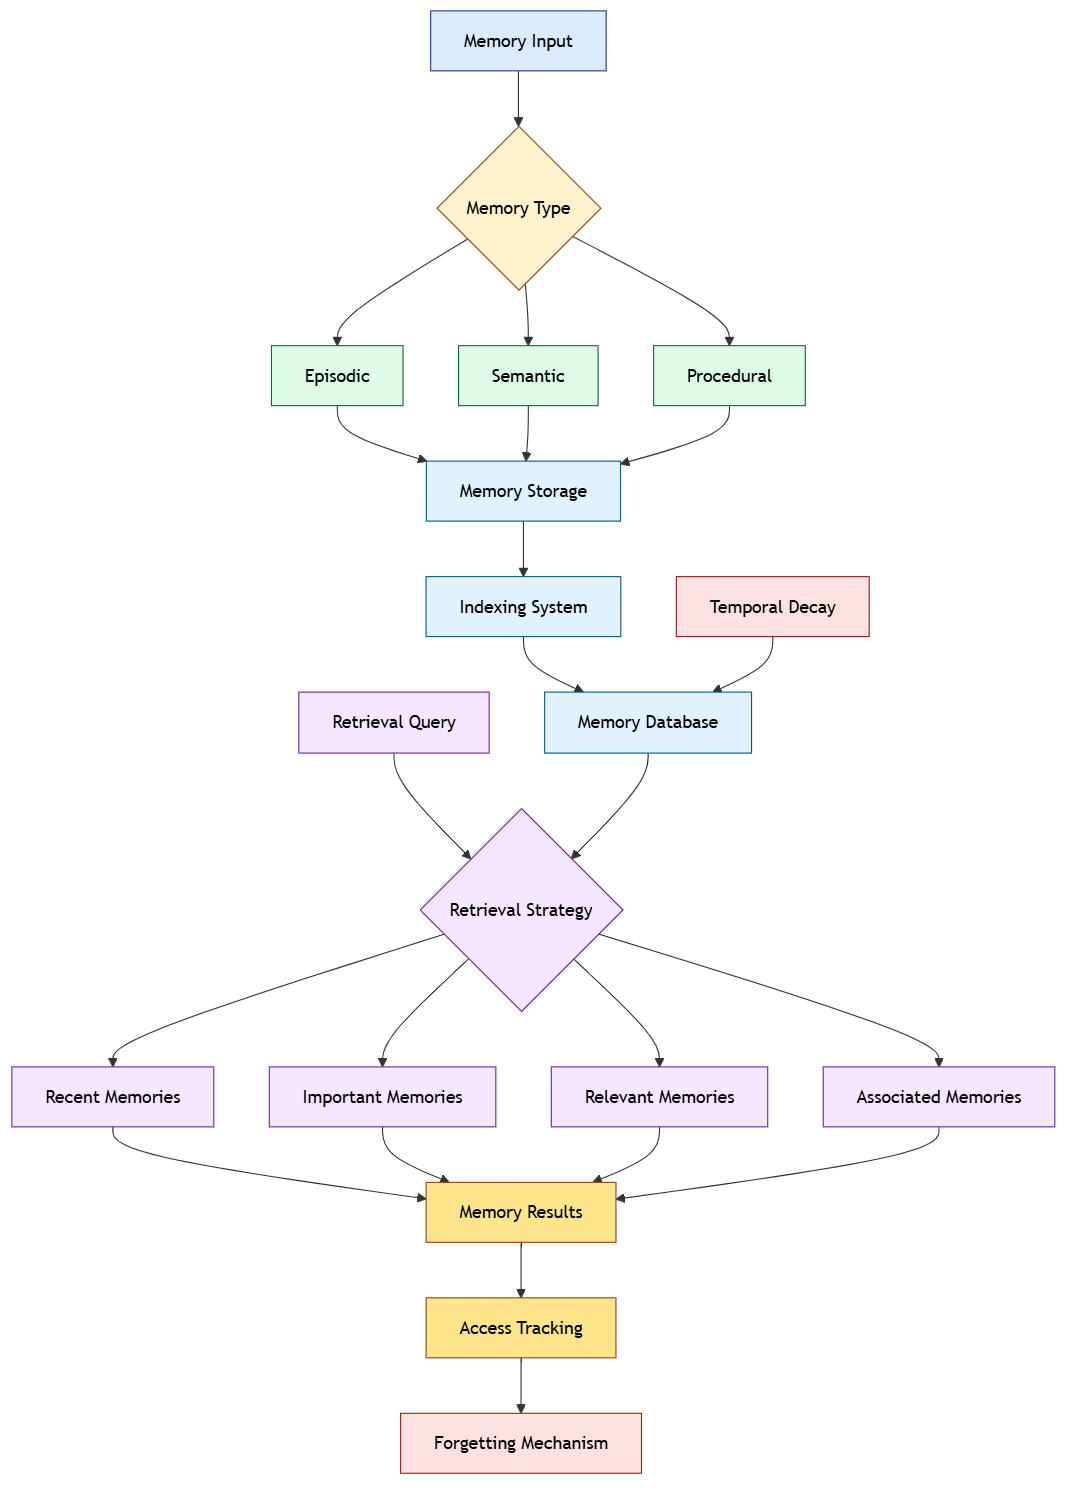

## Desglose del Código Paso a Paso
## Almacenamiento y Organización de la Memoria
### Arquitectura de Memoria de Múltiples Tipos
- Implementa tres categorías de memoria distintas: episódica (experiencias basadas en el tiempo), semántica (hechos y conocimiento) y procedimental (habilidades y procedimientos)
- Organiza las memorias dentro de cada tipo usando subcategorías para una organización eficiente
- Asigna identificadores únicos a cada memoria para un seguimiento y recuperación precisos

### Sistema de Indexación de la Memoria
- Mantiene un índice integral que mapea los IDs de memoria a sus ubicaciones de almacenamiento
- Permite el acceso directo y rápido a cualquier memoria sin buscar a través de todas las categorías
- Admite operaciones eficientes de actualización y eliminación de memorias

## Operaciones de Almacenamiento de la Memoria
### Creación Estructurada de Memorias
- Crea objetos de memoria con metadatos completos, incluyendo marcas de tiempo, puntuaciones de importancia y relaciones
- Asigna automáticamente identificadores únicos crecientes para mantener la secuencia de la memoria
- Registra las operaciones de almacenamiento de memoria para la transparencia y depuración del sistema

### Organización por Subcategorías
- Agrupa las memorias relacionadas dentro de cada tipo de memoria usando subclaves
- Admite una organización flexible de la memoria sin requisitos de esquema rígidos
- Permite la recuperación dirigida dentro de dominios de memoria específicos

## Sistema de Recuperación de la Memoria
### Interfaz de Recuperación de Múltiples Estrategias
- Proporciona cuatro estrategias de recuperación distintas para diferentes necesidades cognitivas
- Aplica el decaimiento de la importancia antes de la recuperación para reflejar la relevancia de la memoria a lo largo del tiempo
- Rastrea los patrones de acceso a la memoria para análisis de uso y optimización

### Recuperación de Memoria Reciente
- Devuelve las memorias almacenadas más recientemente entre todos los tipos
- Ordena las memorias por marca de tiempo en orden descendente
- Útil para la memoria de trabajo y la conciencia del contexto inmediato

### Recuperación de Memoria Importante
- Recupera las memorias con las puntuaciones de importancia actuales más altas
- Refleja la importancia ajustada por decaimiento en lugar de la importancia inicial
- Prioriza las memorias que permanecen relevantes a lo largo del tiempo

### Recuperación de Memoria Relevante
- Implementa la coincidencia de relevancia basada en palabras clave a través del contenido de la memoria
- Admite búsquedas filtradas por tipo para la recuperación específica de un dominio
- Calcula las puntuaciones de relevancia según la frecuencia y las coincidencias de palabras clave

### Recuperación de Memoria Asociada
- Realiza un recorrido basado en grafos a través de las relaciones de la memoria
- Implementa una búsqueda en anchura a través de las redes de memorias relacionadas
- Descubre memorias conectadas contextualmente más allá de las coincidencias directas

## Gestión y Mantenimiento de la Memoria
### Mecanismo de Decaimiento Temporal
- Aplica un decaimiento exponencial a la importancia de la memoria según su antigüedad
- Usa una tasa de decaimiento configurable para controlar la relevancia de la memoria a lo largo del tiempo
- Garantiza que las memorias más antiguas disminuyan gradualmente en prioridad de recuperación a menos que se refuercen

### Olvido y Eliminación de la Memoria
- Proporciona la eliminación precisa de memorias por identificador único
- Actualiza el sistema de indexación para mantener la consistencia tras la eliminación
- Limpia las referencias de relaciones para evitar enlaces rotos
- Reorganiza los índices de memoria para llenar los huecos de las memorias eliminadas

### Seguimiento de Patrones de Acceso
- Monitorea con qué frecuencia se recupera cada memoria
- Proporciona datos para el refuerzo de la importancia de la memoria
- Admite estrategias de optimización de la memoria basadas en el uso

### Conexión con la Lección
- Múltiples Sistemas de Memoria: Demuestra la distinción de la arquitectura cognitiva entre la memoria episódica, semántica y procedimental, conectando con las teorías de la psicología cognitiva
- Decaimiento y Olvido de la Memoria: Implementa mecanismos de decaimiento temporal, relacionándose con la curva del olvido y las teorías de la consolidación de la memoria
- Redes de Memoria Asociativa: Muestra cómo las memorias se conectan mediante relaciones, vinculándose con las redes semánticas y los modelos de activación propagada
- Recuperación Dependiente del Contexto: Proporciona diferentes estrategias de recuperación para diferentes situaciones, conectando con el principio de especificidad de la codificación
- Gestión de la Memoria de Trabajo: Implementa la priorización de la memoria reciente, relacionándose con la capacidad de la memoria de trabajo y los mecanismos de atención
- Refuerzo de la Memoria: Rastrea los patrones de acceso para el ajuste de la importancia, conectando con el fortalecimiento de la memoria basado en el uso
- El Olvido como Función: Demuestra la eliminación controlada de memorias, relacionándose con la gestión de la carga cognitiva y el olvido adaptativo
- Recuperación Eficiente de Información: Muestra estrategias de búsqueda optimizadas, conectando con la teoría de la recuperación de información y los algoritmos de búsqueda cognitiva

In [28]:
# COMPONENT 4: MEMORY SYSTEM

class MemorySystem:
    """
    Handles information storage, retrieval, and management
    Demonstrates different memory types and retrieval strategies
    """
    
    def __init__(self):
        self.memories: Dict[str, Dict[str, List[Memory]]] = {
            "episodic": {},  # Time-based experiences
            "semantic": {},  # Facts and knowledge
            "procedural": {}  # Skills and procedures
        }
        self.memory_index: Dict[str, Tuple[str, str, int]] = {}  # memory_id -> (type, subkey, index)
        self.next_id = 0
        self.decay_rate = 0.05  # Importance decay over time
        self.retrieval_strategies = {
            "recent": self._retrieve_recent,
            "important": self._retrieve_important,
            "relevant": self._retrieve_relevant,
            "associated": self._retrieve_associated
        }
    
    def store(self, content: Any, memory_type: str, importance: float, subkey: str = "general", related: List[str] = None) -> str:
        """
        Store new memory entry
        """
        if memory_type not in self.memories:
            raise ValueError(f"Unknown memory type: {memory_type}")
        
        memory_id = f"mem_{self.next_id}"
        self.next_id += 1
        
        mem = Memory(
            content=content,
            memory_type=memory_type,
            importance=importance,
            timestamp=datetime.now(),
            related_memories=related or [],
            memory_id=memory_id
        )
        
        if subkey not in self.memories[memory_type]:
            self.memories[memory_type][subkey] = []
        
        mem_index = len(self.memories[memory_type][subkey])
        self.memories[memory_type][subkey].append(mem)
        
        self.memory_index[memory_id] = (memory_type, subkey, mem_index)
        
        logger.info(f"💾 Stored {memory_type} memory '{memory_id}' with importance {importance:.2f}")
        return memory_id
    
    def retrieve(self, query: Dict[str, Any], strategy: str = "relevant", limit: int = 5) -> List[Memory]:
        """
        Retrieve memories based on query and strategy
        """
        if strategy not in self.retrieval_strategies:
            raise ValueError(f"Unknown retrieval strategy: {strategy}")
        
        self._apply_decay()  # Decay importance before retrieval
        
        retrieved = self.retrieval_strategies[strategy](query, limit)
        
        # Update access counts
        for mem in retrieved:
            mem.access_count += 1
        
        logger.info(f"🔍 Retrieved {len(retrieved)} memories using {strategy} strategy")
        return retrieved
    
    def forget(self, memory_id: str) -> bool:
        """
        Remove a specific memory
        """
        if memory_id not in self.memory_index:
            return False
        
        mem_type, subkey, mem_index = self.memory_index[memory_id]
        
        # Remove from memory store
        if mem_index < len(self.memories[mem_type][subkey]):
            del self.memories[mem_type][subkey][mem_index]
            
            # Update indices for memories after this one
            for mid, (mt, sk, idx) in list(self.memory_index.items()):
                if mt == mem_type and sk == subkey and idx > mem_index:
                    self.memory_index[mid] = (mt, sk, idx - 1)
        
        del self.memory_index[memory_id]
        
        # Clean up relations
        for mem_type_key in self.memories:
            for sub in self.memories[mem_type_key]:
                for mem in self.memories[mem_type_key][sub]:
                    mem.related_memories = [r for r in mem.related_memories if r != memory_id]
        
        return True
    
    def _apply_decay(self):
        """Apply importance decay to all memories"""
        now = datetime.now()
        for mem_type in self.memories:
            for sub in self.memories[mem_type]:
                for mem in self.memories[mem_type][sub]:
                    days_old = (now - mem.timestamp).days
                    decay_factor = (1 - self.decay_rate) ** days_old
                    mem.importance *= decay_factor
    
    def _get_memory(self, memory_id: str) -> Optional[Memory]:
        """Internal: Get memory by ID"""
        if memory_id in self.memory_index:
            mem_type, subkey, mem_index = self.memory_index[memory_id]
            if mem_index < len(self.memories[mem_type][subkey]):
                return self.memories[mem_type][subkey][mem_index]
        return None
    
    def _retrieve_recent(self, query: Dict[str, Any], limit: int) -> List[Memory]:
        """Retrieve most recent memories"""
        all_memories = []
        for mem_type in self.memories:
            for sub in self.memories[mem_type]:
                all_memories.extend(self.memories[mem_type][sub])
        
        sorted_mem = sorted(all_memories, key=lambda m: m.timestamp, reverse=True)
        return sorted_mem[:limit]
    
    def _retrieve_important(self, query: Dict[str, Any], limit: int) -> List[Memory]:
        """Retrieve most important memories"""
        all_memories = []
        for mem_type in self.memories:
            for sub in self.memories[mem_type]:
                all_memories.extend(self.memories[mem_type][sub])
        
        sorted_mem = sorted(all_memories, key=lambda m: m.importance, reverse=True)
        return sorted_mem[:limit]
    
    def _retrieve_relevant(self, query: Dict[str, Any], limit: int) -> List[Memory]:
        """Retrieve memories relevant to query (simplified keyword match)"""
        keywords = query.get("keywords", [])
        mem_type = query.get("type")
        
        candidates = []
        for mt in [mem_type] if mem_type else self.memories:
            for sub in self.memories[mt]:
                for mem in self.memories[mt][sub]:
                    relevance = sum(1 for kw in keywords if kw.lower() in str(mem.content).lower())
                    if relevance > 0:
                        candidates.append((relevance, mem))
        
        sorted_candidates = sorted(candidates, key=lambda x: x[0], reverse=True)
        return [mem for _, mem in sorted_candidates][:limit]
    
    def _retrieve_associated(self, query: Dict[str, Any], limit: int) -> List[Memory]:
        """Retrieve memories associated with given memory IDs"""
        start_ids = query.get("memory_ids", [])
        visited = set()
        results = []
        
        to_process = list(start_ids)
        while to_process and len(results) < limit:
            current_id = to_process.pop(0)
            if current_id in visited:
                continue
            visited.add(current_id)
            
            mem = self._get_memory(current_id)
            if mem:
                results.append(mem)
                to_process.extend([r for r in mem.related_memories if r not in visited])
        
        return results[:limit]

### Descripción Breve
Este código implementa un sofisticado sistema de planificación que crea planes de múltiples pasos para alcanzar objetivos, gestiona la ejecución de los planes con seguimiento de dependencias y proporciona replanificación dinámica cuando ocurren fallos. Demuestra la descomposición de objetivos, la gestión de dependencias entre pasos, la optimización de costos y la recuperación adaptativa ante fallos de ejecución.

### Lógica del Código y Flujo: Visión General de Alto Nivel
El sistema de planificación opera como un motor jerárquico de consecución de objetivos que descompone los objetivos de alto nivel en pasos ejecutables, gestiona las dependencias y el orden de ejecución de los pasos, monitorea el progreso del plan y regenera dinámicamente los planes cuando se encuentran obstáculos. Mantiene un historial de planes y proporciona una optimización consciente de los costos para garantizar una búsqueda eficiente de los objetivos.

### Diagrama de Flujo Visual
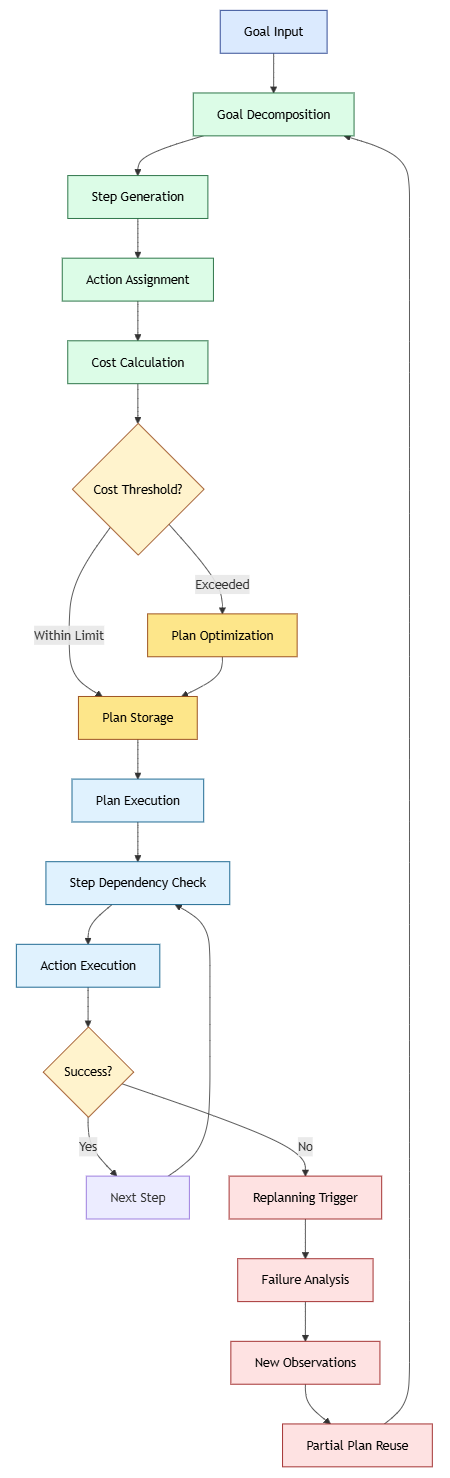

## Desglose del Código Paso a Paso
## Estructura del Plan y Modelo de Datos
### Definición del Paso del Plan
- Crea objetos de paso completos con descripciones, acciones y dependencias
- Rastrea el estado del paso a través de su ciclo de vida de ejecución (pendiente, en ejecución, completado, fallido, bloqueado, abortado)
- Gestiona las dependencias de los pasos para garantizar el orden de ejecución correcto
- Estima los costos para la planificación de recursos y la optimización

### Sistema de Gestión de Planes
- Mantiene múltiples planes concurrentes con identificadores únicos
- Almacena el historial completo de planes para el análisis y el aprendizaje
- Impone restricciones configurables sobre la complejidad y los costos del plan

## Proceso de Creación del Plan
### Motor de Descomposición de Objetivos
- Descompone los objetivos de alto nivel en pasos secuenciales ejecutables
- Usa coincidencia de patrones basada en palabras clave para los tipos de objetivo comunes
- Proporciona una descomposición de reserva para los tipos de objetivo desconocidos
- Genera descripciones de pasos que definen claramente los subobjetivos

### Mecanismo de Selección de Acciones
- Mapea las descripciones de los pasos a los tipos de acción apropiados usando el análisis de palabras clave
- Admite la asignación flexible de acciones según los requisitos del paso
- Proporciona una selección de acción de reserva cuando no hay coincidencias específicas disponibles
- Garantiza que cada paso tenga una acción concreta y ejecutable

### Gestión y Optimización de Costos
- Calcula el costo total del plan sumando los costos de los pasos individuales
- Aplica la verificación de umbrales de costo para evitar planes ineficientes
- Implementa estrategias de optimización como la eliminación o fusión de pasos
- Equilibra la integridad del plan frente a las restricciones de recursos

## Gestión de la Ejecución del Plan
### Ejecución Secuencial con Verificación de Dependencias
- Ejecuta los pasos del plan en orden respetando las restricciones de dependencia
- Verifica que todos los pasos prerrequisito estén completados antes de continuar
- Maneja los pasos bloqueados cuando no se cumplen las dependencias
- Proporciona un seguimiento claro del estado de cada paso

### Detección y Manejo de Fallos
- Monitorea los resultados de la ejecución de las acciones en busca del estado de éxito/fracaso
- Detecta automáticamente los fallos de los pasos durante la ejecución
- Activa los procedimientos de replanificación cuando ocurren fallos
- Evita la continuación de los planes tras fallos críticos

## Sistema de Replanificación Dinámica
### Mecanismo de Recuperación ante Fallos
- Preserva los pasos completados exitosamente de los planes fallidos
- Identifica el punto exacto del fallo para una replanificación dirigida
- Genera nuevos pasos para abordar los objetivos restantes
- Mantiene la continuidad entre los planes originales y los revisados

### Reutilización Parcial del Plan
- Retiene los pasos completados para evitar trabajo redundante
- Recalcula las dependencias para las nuevas secuencias de pasos
- Crea nuevos identificadores de plan para distinguir las versiones revisadas
- Aprovecha el progreso previo mientras se adapta a las nuevas restricciones

## Funciones de Apoyo
### Patrones de Descomposición Específicos por Objetivo
- Implementa una descomposición especializada para los objetivos de exploración
- Proporciona secuencias de pasos orientadas a la resolución de problemas
- Ofrece una descomposición genérica para los tipos de objetivo desconocidos
- Garantiza una granularidad apropiada para las diferentes categorías de objetivos

### Lógica de Mapeo de Acción a Paso
- Analiza las descripciones de los pasos para determinar las acciones apropiadas
- Mapea los pasos analíticos a acciones de análisis
- Asigna acciones de observación a los pasos de escaneo e identificación
- Vincula las acciones de movimiento y manipulación a los pasos de implementación física

### Conexión con la Lección
- Redes de Tareas Jerárquicas: Demuestra la descomposición de objetivos en subtareas, conectando con la teoría de planificación HTN
- Planificación de Orden Parcial: Muestra la gestión de dependencias entre los pasos del plan, relacionándose con los algoritmos de planificación de orden parcial
- Replanificación y Adaptación: Implementa la revisión dinámica de planes, conectando con la planificación del mundo real bajo incertidumbre
- Planificación Acotada por Costos: Aplica restricciones de recursos y optimización, relacionándose con la racionalidad limitada y el satisficing
- Monitoreo de la Ejecución: Rastrea el progreso del plan y detecta fallos, vinculándose con los sistemas de ejecución de bucle cerrado
- Reutilización de Planes: Preserva los pasos exitosos durante la replanificación, conectando con la planificación basada en casos y la reutilización de la experiencia
- Gestión de Dependencias: Garantiza la secuenciación correcta de los pasos, relacionándose con el mantenimiento de enlaces causales en la planificación
- Comportamiento Orientado a Objetivos: Muestra cómo los objetivos abstractos se traducen en acciones concretas, encarnando los principios del análisis de medios y fines

In [25]:
# COMPONENT 5: PLANNING SYSTEM


@dataclass
class PlanStep:
    """Individual step in a plan"""
    description: str
    action: Action
    dependencies: List[int]  # Step indices this depends on
    estimated_cost: float
    status: str = "pending"  # pending, executing, completed, failed

class PlanningSystem:
    """
    Handles creation and management of multi-step plans
    Demonstrates goal decomposition, dependency management, and replanning
    """
    
    def __init__(self):
        self.plans: Dict[str, List[PlanStep]] = {}
        self.plan_history = []
        self.max_steps = 10
        self.cost_threshold = 100.0
    
    def create_plan(self, goal: str, current_state: Dict[str, Any], available_actions: List[str]) -> str:
        """
        Create a new plan for achieving a goal
        """
        plan_id = f"plan_{len(self.plans)}"
        
        # Decompose goal into steps (simplified decomposition)
        steps = self._decompose_goal(goal, current_state)
        
        # Create PlanSteps
        plan_steps = []
        for i, step_desc in enumerate(steps):
            action_type = self._select_action_for_step(step_desc, available_actions)
            action = Action(
                action_type=action_type,
                parameters={"goal_step": step_desc},
                expected_outcome=f"complete_{step_desc.lower().replace(' ', '_')}",
                cost=random.uniform(5, 20)
            )
            deps = [i-1] if i > 0 else []
            plan_steps.append(PlanStep(
                description=step_desc,
                action=action,
                dependencies=deps,
                estimated_cost=action.cost
            ))
        
        # Check total cost
        total_cost = sum(s.estimated_cost for s in plan_steps)
        if total_cost > self.cost_threshold:
            logger.warning(f"Plan cost {total_cost:.2f} exceeds threshold - optimizing")
            plan_steps = self._optimize_plan(plan_steps)
        
        self.plans[plan_id] = plan_steps
        self.plan_history.append({"goal": goal, "plan_id": plan_id, "initial_steps": len(plan_steps)})
        
        logger.info(f"📋 Created plan '{plan_id}' with {len(plan_steps)} steps for goal: {goal}")
        return plan_id
    
    def execute_plan(self, plan_id: str, action_system: ActionSystem) -> Dict[str, Any]:
        """
        Execute the plan step by step
        """
        if plan_id not in self.plans:
            raise ValueError(f"Unknown plan: {plan_id}")
        
        plan = self.plans[plan_id]
        results = []
        failed = False
        
        for i, step in enumerate(plan):
            if failed:
                step.status = "aborted"
                continue
            
            # Check dependencies
            if not all(plan[d].status == "completed" for d in step.dependencies):
                step.status = "blocked"
                continue
            
            step.status = "executing"
            action_results = action_system.execute_actions([step.action])
            results.extend(action_results)
            
            if all(r["success"] for r in action_results):
                step.status = "completed"
            else:
                step.status = "failed"
                failed = True
                logger.warning(f"Plan step {i} failed - triggering replan")
        
        execution_summary = {
            "plan_id": plan_id,
            "completed_steps": sum(1 for s in plan if s.status == "completed"),
            "total_steps": len(plan),
            "success": not failed,
            "results": results
        }
        
        logger.info(f"🏁 Plan execution {'succeeded' if not failed else 'failed'} with {execution_summary['completed_steps']}/{len(plan)} steps completed")
        return execution_summary
    
    def replan(self, plan_id: str, failure_point: int, new_observations: List[Observation]) -> str:
        """
        Replan from failure point
        """
        if plan_id not in self.plans:
            raise ValueError(f"Unknown plan: {plan_id}")
        
        old_plan = self.plans[plan_id]
        new_steps = old_plan[:failure_point]  # Keep completed steps
        
        # Generate new steps from failure point
        remaining_goal = " ".join([s.description for s in old_plan[failure_point:]])
        new_decomposed = self._decompose_goal(remaining_goal, {"observations": new_observations})
        
        for i, step_desc in enumerate(new_decomposed, start=len(new_steps)):
            action_type = self._select_action_for_step(step_desc, [])
            action = Action(
                action_type=action_type,
                parameters={"goal_step": step_desc},
                expected_outcome=f"complete_{step_desc.lower().replace(' ', '_')}",
                cost=random.uniform(5, 20)
            )
            deps = [len(new_steps)-1] if len(new_steps) > 0 else []
            new_steps.append(PlanStep(
                description=step_desc,
                action=action,
                dependencies=deps,
                estimated_cost=action.cost
            ))
        
        new_plan_id = f"{plan_id}_replan"
        self.plans[new_plan_id] = new_steps
        
        logger.info(f"🔄 Replanned from step {failure_point}: new plan '{new_plan_id}' with {len(new_steps)} steps")
        return new_plan_id
    
    def _decompose_goal(self, goal: str, state: Dict[str, Any]) -> List[str]:
        """Decompose goal into steps (simulated)"""
        # Mock decomposition based on goal keywords
        if "explore" in goal.lower():
            return ["scan_environment", "identify_points_of_interest", "approach_target"]
        elif "solve" in goal.lower():
            return ["analyze_problem", "generate_solutions", "select_best", "implement"]
        else:
            return [f"step_{i+1}_{goal.lower()[:20]}" for i in range(random.randint(3, 5))]
    
    def _select_action_for_step(self, step_desc: str, available: List[str]) -> str:
        """Select appropriate action for step"""
        if "analyze" in step_desc.lower():
            return "analyze"
        elif "scan" in step_desc.lower() or "identify" in step_desc.lower():
            return "observe"
        elif "approach" in step_desc.lower() or "implement" in step_desc.lower():
            return "move" if "approach" in step_desc else "manipulate"
        return random.choice(available or ["observe", "analyze", "manipulate"])
    
    def _optimize_plan(self, plan: List[PlanStep]) -> List[PlanStep]:
        """Optimize plan by removing or merging steps (simplified)"""
        # Remove last step if possible
        if len(plan) > 2:
            return plan[:-1]
        return plan

### Descripción Breve
Este código implementa un agente inteligente totalmente integrado que combina los sistemas de percepción, razonamiento, acción, memoria y planificación en una arquitectura cognitiva cohesiva. Demuestra el bucle completo de acción-reflexión, donde el agente percibe continuamente su entorno, razona sobre las observaciones, ejecuta las acciones planificadas y reflexiona sobre los resultados para mejorar el rendimiento futuro.

### Lógica del Código y Flujo: Visión General de Alto Nivel
El agente opera a través de un ciclo cognitivo continuo que comienza con la percepción del entorno, avanza a través del razonamiento mejorado por la memoria y la planificación orientada a objetivos, ejecuta las acciones seleccionadas y culmina en el aprendizaje reflexivo. Esto crea un sistema de bucle cerrado donde cada ciclo informa al siguiente, permitiendo que el agente adapte su comportamiento según la experiencia y trabaje progresivamente hacia sus objetivos.

### Diagrama de Flujo Visual
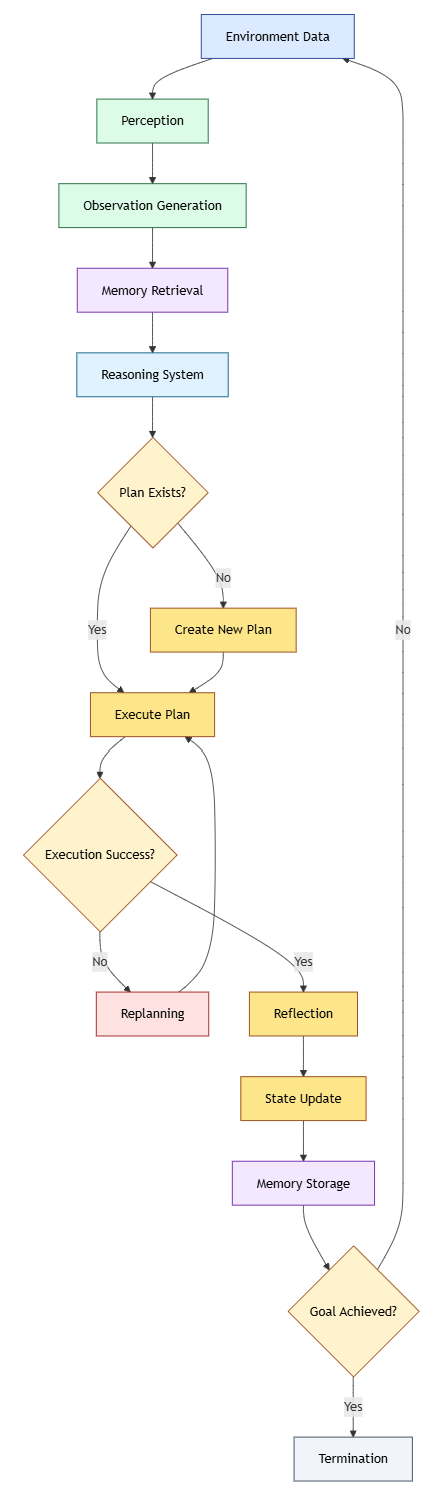

## Desglose del Código Paso a Paso
## Inicialización del Agente y Establecimiento de Objetivos
### Integración de Componentes
- Instancia los cinco sistemas cognitivos centrales: percepción, razonamiento, acción, memoria y planificación
- Establece canales de comunicación entre los componentes para un flujo de datos fluido
- Inicializa el estado del agente con condiciones ambientales por defecto

### Sistema de Gestión de Objetivos
- Permite la asignación dinámica de objetivos durante la operación del agente
- Almacena los objetivos en la memoria semántica para referencia a largo plazo
- Mantiene la persistencia de los objetivos a lo largo de múltiples ciclos cognitivos

## Ejecución del Ciclo Cognitivo Principal
### Fase de Percepción
- Procesa los datos ambientales crudos a través del sistema de percepción multisensorial
- Genera observaciones estructuradas con puntuación de confianza
- Aplica el filtrado por atención para enfocarse en las características ambientales relevantes

### Recuperación de Memoria Consciente del Contexto
- Consulta el sistema de memoria en busca de experiencias relevantes para el objetivo actual
- Recupera memorias episódicas recientes para informar el razonamiento actual
- Proporciona contexto histórico para una mejor toma de decisiones

### Razonamiento con Contexto Integrado
- Combina las observaciones actuales con las memorias recuperadas
- Aplica múltiples estrategias de razonamiento según el contexto situacional
- Genera decisiones con puntuación de confianza y acciones recomendadas

### Gestión de la Planificación Dinámica
- Crea nuevos planes cuando no existe un plan activo para el objetivo actual
- Mantiene la continuidad del plan a lo largo de múltiples ciclos de ejecución
- Gestiona los identificadores de plan en el estado del agente para un seguimiento persistente

## Ejecución de Acciones y Adaptación
### Ejecución del Plan con Monitoreo
- Ejecuta los pasos planificados a través del sistema de acción
- Rastrea la finalización de los pasos y las tasas de éxito en tiempo real
- Gestiona las dependencias de los pasos y el orden de ejecución

### Recuperación ante Fallos mediante Replanificación
- Detecta los fallos de ejecución y el progreso incompleto del plan
- Activa la replanificación dinámica desde el punto del fallo
- Preserva los pasos exitosos mientras genera nuevos enfoques
- Mantiene el enfoque en el objetivo a pesar de los obstáculos de ejecución

## Fase de Reflexión y Aprendizaje
### Evaluación del Rendimiento
- Calcula las puntuaciones de éxito según los resultados de la ejecución de las acciones
- Estima el progreso hacia el objetivo mediante métricas de logro simuladas
- Evalúa la confianza del razonamiento y la calidad de las observaciones

### Extracción del Aprendizaje
- Identifica las lecciones aprendidas del rendimiento del ciclo
- Genera perspectivas estratégicas para la mejora futura
- Destila la experiencia en conocimiento accionable

### Adaptación del Estado
- Actualiza el estado del entorno según los resultados del rendimiento
- Ajusta el modelo del mundo del agente para reflejar la nueva comprensión
- Mantiene un registro histórico de los ciclos cognitivos para su análisis

### Consolidación de la Experiencia
- Almacena las experiencias completas del ciclo en la memoria episódica
- Registra las observaciones, los enfoques de razonamiento, los resultados de la ejecución y las reflexiones
- Aplica la puntuación de importancia según el éxito y el valor de aprendizaje

### Conexión con la Lección
- Arquitectura Cognitiva: Demuestra el ciclo completo de percibir-pensar-actuar, conectando con las arquitecturas clásicas de agentes de IA
- Bucle de Acción-Reflexión: Implementa la práctica reflexiva central que permite el aprendizaje y la adaptación continuos
- Comportamiento Orientado a Objetivos: Muestra cómo los agentes mantienen la búsqueda persistente de objetivos a lo largo de múltiples ciclos, relacionándose con la autonomía dirigida por objetivos
- Sistemas Cognitivos Integrados: Ilustra cómo los sistemas de percepción, razonamiento, memoria y acción trabajan juntos, conectando con las teorías cognitivas unificadas
- Planificación Adaptativa: Demuestra el ajuste de planes en tiempo real según la retroalimentación de la ejecución, relacionándose con la planificación situada y los sistemas reactivos
- Aprendizaje Basado en Experiencias: Muestra cómo los agentes aprenden de cada ciclo y almacenan las lecciones en la memoria, conectando con el aprendizaje por refuerzo y el razonamiento basado en casos
- Monitoreo del Rendimiento: Implementa la autoevaluación continua y la actualización del estado, encarnando capacidades metacognitivas
- Inteligencia de Bucle Cerrado: Crea un sistema de retroalimentación completo donde los resultados informan las decisiones futuras, relacionándose con los sistemas de control cibernético y el comportamiento adaptativo

In [26]:
# COMPONENT 6: AGENT INTEGRATION AND ACTION/REFLECTION LOOP

class Agent:
    """
    Integrates all components into a functional agent
    Demonstrates the action/reflection loop
    """
    
    def __init__(self):
        self.perception = PerceptionSystem()
        self.reasoning = ReasoningSystem()
        self.action = ActionSystem()
        self.memory = MemorySystem()
        self.planning = PlanningSystem()
        self.current_goal = None
        self.current_state = {"environment": EnvironmentState.STABLE.value}
        self.loop_history = []
    
    def set_goal(self, goal: str):
        """Set the agent's primary goal"""
        self.current_goal = goal
        self.memory.store(goal, "semantic", 1.0, "goals")
        logger.info(f"🎯 New goal set: {goal}")
    
    def run_loop(self, environment_data: Dict[str, Any], max_cycles: int = 5) -> List[Dict[str, Any]]:
        """
        Main action/reflection loop
        """
        cycle_results = []
        
        for cycle in range(max_cycles):
            logger.info(f"\n🔄 Starting cycle {cycle + 1}/{max_cycles}")
            
            # Perceive
            observations = self.perception.perceive(environment_data)
            
            # Retrieve relevant memories
            mem_query = {"keywords": [self.current_goal] if self.current_goal else [], "type": "episodic"}
            relevant_memories = self.memory.retrieve(mem_query, strategy="recent", limit=3)
            
            # Reason
            context = {
                "current_state": self.current_state,
                "memories": [m.content for m in relevant_memories],
                "goal": self.current_goal
            }
            reasoning = self.reasoning.reason(observations, context, self.current_goal)
            
            # Plan or replan if needed
            if "plan_id" not in self.current_state:
                plan_id = self.planning.create_plan(self.current_goal, self.current_state, list(self.action.available_actions.keys()))
                self.current_state["plan_id"] = plan_id
            else:
                plan_id = self.current_state["plan_id"]
            
            # Act
            plan_execution = self.planning.execute_plan(plan_id, self.action)
            if not plan_execution["success"] and plan_execution["completed_steps"] < plan_execution["total_steps"]:
                new_plan_id = self.planning.replan(plan_id, plan_execution["completed_steps"], observations)
                self.current_state["plan_id"] = new_plan_id
                plan_execution = self.planning.execute_plan(new_plan_id, self.action)
            
            # Reflect
            reflection = self._reflect(cycle, observations, reasoning, plan_execution)
            
            # Update state and memory
            self._update_state(reflection)
            self.memory.store({
                "observations": len(observations),
                "reasoning": reasoning.get("primary_reasoning"),
                "execution": plan_execution["success"],
                "reflection": reflection
            }, "episodic", reflection["success_score"], "cycles")
            
            cycle_results.append(reflection)
            
            if reflection["goal_achieved"]:
                logger.info("✅ Goal achieved - ending loop")
                break
        
        return cycle_results
    
    def _reflect(self, cycle: int, observations: List[Observation], reasoning: Dict, execution: Dict) -> Dict[str, Any]:
        """Reflect on the cycle's performance"""
        success_score = sum(1 for r in execution["results"] if r["success"]) / len(execution["results"]) if execution["results"] else 0
        goal_progress = min(0.3 * (cycle + 1), 1.0)  # Simulated progress
        
        reflection = {
            "cycle": cycle,
            "observations_count": len(observations),
            "reasoning_confidence": reasoning["confidence"],
            "execution_success": execution["success"],
            "success_score": success_score,
            "goal_progress": goal_progress,
            "goal_achieved": goal_progress >= 1.0 or (cycle == 4 and random.random() > 0.5),
            "lessons_learned": ["optimize_actions" if success_score < 0.7 else "maintain_strategy"]
        }
        
        logger.info(f"🤔 Reflection: Success score {success_score:.2f}, Progress {goal_progress:.2f}")
        return reflection
    
    def _update_state(self, reflection: Dict[str, Any]):
        """Update agent state based on reflection"""
        if reflection["success_score"] < 0.5:
            self.current_state["environment"] = EnvironmentState.UNCERTAIN.value
        elif reflection["success_score"] > 0.8:
            self.current_state["environment"] = EnvironmentState.STABLE.value
        
        self.loop_history.append(reflection)



### Descripción Breve
Este código demuestra un sistema de agente inteligente totalmente operativo creando un escenario realista donde un agente debe responder a un visitante. Muestra cómo todos los componentes integrados trabajan juntos en la práctica, desde la configuración del entorno hasta la consecución del objetivo, proporcionando un ejemplo concreto de la arquitectura completa del agente en acción.

### Lógica del Código y Flujo: Visión General de Alto Nivel
La demostración crea un escenario de entorno realista con múltiples entradas sensoriales, inicializa un sistema de agente completo, establece un objetivo específico para que el agente lo alcance y luego ejecuta el agente a través de múltiples ciclos cognitivos para observar cómo procesa la información, toma decisiones, ejecuta acciones y progresa hacia su objetivo. Los resultados finales se muestran para evidenciar el rendimiento y el aprendizaje del agente a lo largo del proceso.

### Diagrama de Flujo Visual
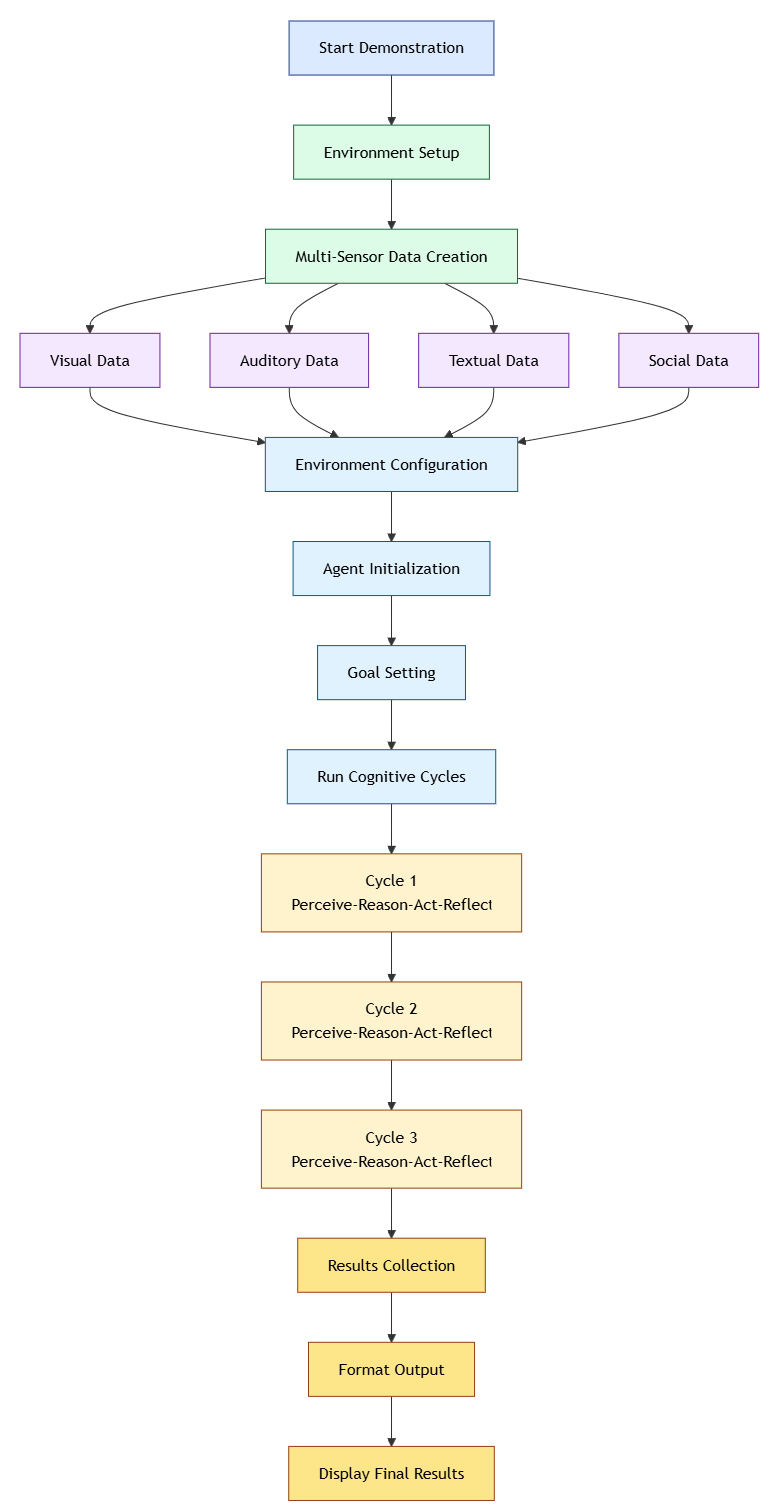

## Desglose del Código Paso a Paso
## Creación del Escenario del Entorno
### Configuración del Entorno Multimodal
- Crea un entorno integral con cuatro modalidades sensoriales diferentes
- Diseña un escenario realista que involucra a un visitante en una puerta
- Proporciona datos ricos y contextuales para que el agente los procese

### Configuración del Entorno Visual
- Define objetos físicos en el entorno, incluyendo una puerta con atributos específicos
- Establece el contexto de la escena como un entorno de habitación
- Proporciona información espacial sobre las posiciones de los objetos

### Configuración del Entorno Auditivo
- Incluye datos sonoros con sonidos de golpes a un volumen moderado
- Proporciona señales auditivas temporales para que el agente las interprete
- Crea contexto situacional mediante patrones sonoros

### Contexto de Comunicación Textual
- Añade instrucciones textuales explícitas mediante mensajes
- Proporciona una entrada direccional clara para el agente
- Crea requisitos de tarea basados en la comunicación

### Definición del Contexto Social
- Incluye personas presentes en el entorno con atributos específicos
- Define señales sociales mediante indicadores de estado de ánimo
- Crea requisitos de interacción interpersonal

## Inicialización del Sistema del Agente
### Instanciación Completa del Agente
- Crea un agente totalmente integrado con los cinco sistemas cognitivos
- Inicializa los componentes de percepción, razonamiento, acción, memoria y planificación
- Establece todos los canales de comunicación internos entre los sistemas

### Proceso de Asignación de Objetivos
- Establece un objetivo específico y accionable para que el agente lo alcance
- Almacena el objetivo en el sistema de memoria semántica del agente
- Proporciona un objetivo claro hacia el cual trabajarán los ciclos cognitivos

## Ejecución del Ciclo Cognitivo
### Operación de Múltiples Ciclos
- Ejecuta el agente a través de tres ciclos cognitivos completos
- Demuestra el aprendizaje y la adaptación progresivos a lo largo del tiempo
- Muestra cómo el agente refina su enfoque a través de la experiencia

### Operación Integrada del Sistema
- Ejecuta el bucle completo de percibir-razonar-actuar-reflexionar
- Muestra la interacción en tiempo real entre todos los componentes cognitivos
- Demuestra cómo la memoria informa al razonamiento y la planificación

## Análisis y Visualización de Resultados
### Recopilación de Datos de Rendimiento
- Recopila resultados completos de todos los ciclos cognitivos
- Captura métricas de éxito, resultados de aprendizaje y progreso hacia el objetivo
- Documenta el proceso de toma de decisiones y las adaptaciones del agente

### Formato de Salida Legible por Humanos
- Convierte los datos complejos del agente en un formato JSON comprensible
- Preserva la secuencia temporal y las relaciones causales
- Proporciona una visión clara de los procesos internos del agente

### Conexión con la Lección
- Demostración de Sistema Integrado: Muestra cómo todos los componentes del agente trabajan juntos en la práctica, conectando con las teorías de la arquitectura cognitiva unificada
- Prueba en Escenario del Mundo Real: Demuestra el rendimiento del agente en una situación creíble, relacionándose con la cognición situada y la IA corporizada
- Aprendizaje de Múltiples Ciclos: Ilustra cómo los agentes mejoran a lo largo de múltiples iteraciones, conectando con las teorías del aprendizaje incremental y la adaptación
- Medición del Rendimiento: Proporciona métricas concretas para evaluar el éxito del agente, relacionándose con los marcos de evaluación de agentes
- Complejidad Ambiental: Muestra agentes que manejan múltiples entradas simultáneas, conectando con la riqueza del entorno del mundo real
- Comportamiento Orientado a Objetivos: Demuestra la búsqueda persistente de objetivos a lo largo de los ciclos, encarnando la intencionalidad en los sistemas de IA
- Operación Transparente: Hace visibles los procesos internos mediante una salida detallada, relacionándose con la IA explicable y los sistemas interpretables
- Funcionalidad de Principio a Fin: Completa el ciclo completo desde la percepción hasta la acción y la reflexión, conectando con la gestión integral del ciclo de vida del agente

In [27]:
# DEMONSTRATION


if __name__ == "__main__":
    # Sample environment data
    env_data = {
        "visual": {
            "objects": [{"name": "door", "position": "front", "attributes": {"locked": False}}],
            "scene": "room"
        },
        "auditory": {
            "sounds": [{"type": "knock", "volume": 60}]
        },
        "textual": {
            "messages": ["Open the door"]
        },
        "people_present": [{"name": "visitor", "mood": "impatient"}]
    }
    
    # Create and run agent
    agent = Agent()
    agent.set_goal("Respond to visitor")
    results = agent.run_loop(env_data, max_cycles=3)
    
    print("\nFinal Results:")
    print(json.dumps(results, default=str, indent=2))

2025-10-26 12:22:44,987 - 💾 Stored semantic memory 'mem_0' with importance 1.00
2025-10-26 12:22:44,987 - 🎯 New goal set: Respond to visitor
2025-10-26 12:22:44,988 - 
🔄 Starting cycle 1/3
2025-10-26 12:22:44,989 - 🔍 Perceived 4 significant observations
2025-10-26 12:22:44,989 - 🔍 Retrieved 1 memories using recent strategy
2025-10-26 12:22:44,989 - 🧠 Reasoning complete: composite with 1.00 confidence
2025-10-26 12:22:44,990 - 📋 Created plan 'plan_0' with 3 steps for goal: Respond to visitor
2025-10-26 12:22:44,990 - 🎯 Executing action: wait
2025-10-26 12:22:45,991 - 🎯 Executing action: wait
2025-10-26 12:22:46,997 - 🎯 Executing action: wait
2025-10-26 12:22:48,007 - 🏁 Plan execution succeeded with 3/3 steps completed
2025-10-26 12:22:48,008 - 🤔 Reflection: Success score 1.00, Progress 0.30
2025-10-26 12:22:48,009 - 💾 Stored episodic memory 'mem_1' with importance 1.00
2025-10-26 12:22:48,009 - 
🔄 Starting cycle 2/3
2025-10-26 12:22:48,010 - 🔍 Perceived 4 significant observations
2025-1


Final Results:
[
  {
    "cycle": 0,
    "observations_count": 4,
    "reasoning_confidence": 1.0,
    "execution_success": true,
    "success_score": 1.0,
    "goal_progress": 0.3,
    "goal_achieved": false,
    "lessons_learned": [
      "maintain_strategy"
    ]
  },
  {
    "cycle": 1,
    "observations_count": 4,
    "reasoning_confidence": 1.0,
    "execution_success": true,
    "success_score": 1.0,
    "goal_progress": 0.6,
    "goal_achieved": false,
    "lessons_learned": [
      "maintain_strategy"
    ]
  },
  {
    "cycle": 2,
    "observations_count": 4,
    "reasoning_confidence": 1.0,
    "execution_success": true,
    "success_score": 1.0,
    "goal_progress": 0.8999999999999999,
    "goal_achieved": false,
    "lessons_learned": [
      "maintain_strategy"
    ]
  }
]
